# Beer Brewing Process Simulation with NeqSim Bio-Processing

A rigorous, step-by-step thermodynamic and kinetic simulation of the beer brewing process
using NeqSim's bio-processing equipment and the **CPA equation of state** for accurate
modelling of associating fluids (water, ethanol, glycerol).

## Process Overview

```
Malt Slurry                                                    
    │                                                           
    ▼                                                           
┌──────────────┐    ┌──────────────┐    ┌──────────────────┐
│   MASHING    │───►│  LAUTERING   │───►│  WORT BOILING    │
│ EnzymeTreat. │    │ SolidsSep.   │    │  Heater/Cooler   │
│ (65 °C, 1hr) │    │ (grain sep.) │    │  (100 °C, 1hr)   │
└──────────────┘    └──────────────┘    └──────────────────┘
                                                │              
                                                ▼              
                                        ┌──────────────────┐   
                                        │  FERMENTATION    │   
                                        │  Fermenter       │   
                                        │ Glucose→EtOH+CO₂ │   
                                        │  (20 °C, 5 days) │   
                                        └──────────────────┘   
                                                │              
                                                ▼              
                                        ┌──────────────────┐   
                                        │  CONDITIONING    │   
                                        │  Cooler          │   
                                        │   (2 °C)         │   
                                        └──────────────────┘   
                                                │              
                                                ▼              
                                            🍺 Beer           
```

## Key Equations

**Alcoholic Fermentation (Gay-Lussac equation):**

$$C_6H_{12}O_6 \longrightarrow 2\,C_2H_5OH + 2\,CO_2$$

- 1 mol glucose (180 g) → 2 mol ethanol (92 g) + 2 mol CO₂ (88 g)
- Theoretical yield: 51.1% ethanol by mass

**Monod Kinetics (microbial growth):**

$$\mu = \mu_{max} \cdot \frac{S}{K_S + S}$$

where $\mu$ is the specific growth rate (1/hr), $S$ is substrate concentration (g/L),
$K_S$ is the half-saturation constant, and $\mu_{max}$ is the maximum growth rate.

**CPA Equation of State** (for water–ethanol–CO₂ VLE):

$$P = \frac{RT}{V_m - b} - \frac{a(T)}{V_m(V_m + b)} + P_{assoc}$$

where $P_{assoc}$ accounts for hydrogen bonding between water and ethanol molecules.

## Learning Objectives

By working through this notebook you will learn to:

- **Thermodynamic modelling of food systems** — Use the CPA (Cubic-Plus-Association)
  equation of state to model hydrogen-bonding fluids like water, ethanol, and sugars
- **Vapour–liquid equilibrium (VLE)** — Predict CO₂ solubility in beer at
  different temperatures and pressures using rigorous flash calculations
- **Enzyme kinetics** — Model starch-to-sugar conversion during mashing
  with Michaelis–Menten kinetics and temperature-dependent enzyme activity
- **Fermentation biochemistry** — Simulate anaerobic yeast fermentation with
  Monod growth kinetics, ethanol inhibition, and stoichiometric mass balances
- **Multi-sugar fermentation** — Model sequential glucose → maltose → maltotriose
  uptake with competitive inhibition (catabolite repression) and diauxic lag
- **Process simulation** — Wire individual unit operations into a complete
  `ProcessSystem` flowsheet and perform sensitivity analyses
- **Electrolyte thermodynamics** — Predict beer pH from first-principles
  CO₂–carbonate chemical equilibrium using the electrolyte CPA model
- **Organic acid pH modelling** — Couple Monod kinetics with Henderson-Hasselbalch
  to predict pH drop during fermentation from lactic, acetic, succinic, and citric acid production
- **Water chemistry** — Calculate residual alkalinity, Cl:SO₄ ratios, and mash pH
  from brewing salt additions using electrolyte CPA
- **Hop isomerization kinetics** — Predict IBU from hop schedule using Tinseth
  utilisation and Arrhenius temperature correction for sub-boiling additions
- **Brewing science** — Understand how mash temperature, fermentation
  temperature, water chemistry, and carbonation pressure affect the final beer
- **Real recipe analysis** — Compare simulation predictions against a real
  Norwegian NEIPA recipe (E.C. Dahls G.O.D.S.) brewed on a Grainfather G30v3

**Prerequisites:** Basic Python, introductory chemistry (moles, reactions, equilibrium).
No prior brewing or thermodynamics knowledge is required.

## Step 1 — Imports and Environment Setup

We import NeqSim via the `jneqsim` gateway, which auto-starts the JVM. We use:

- **`SystemSrkCPAstatoil`** — CPA equation of state for associating fluids (water, ethanol)
- **Bio-processing equipment** — `Fermenter`, `EnzymeTreatment`, `StoichiometricReaction`
- **Separation** — `SolidsSeparator` for lautering (grain removal)
- **Heat exchange** — `Heater`/`Cooler` for wort boiling and conditioning
- **COMP_EXT database** — extended component database containing glucose, glycerol, etc.

In [ ]:
# ─────────────────────────────────────────────────────────────
# Option B: NeqSim devtools setup (for Java developers)
# ─────────────────────────────────────────────────────────────
from neqsim_dev_setup import neqsim_init, neqsim_classes
import jpype

# Start JVM with project classpath (set recompile=True to rebuild Java first)
ns = neqsim_init(recompile=False)

# Import standard NeqSim classes into namespace
ns = neqsim_classes(ns)

# Extract standard classes into local scope (so rest of notebook works unchanged)
SystemSrkCPAstatoil  = ns.SystemSrkCPAstatoil
ThermodynamicOperations = ns.ThermodynamicOperations
ProcessSystem        = ns.ProcessSystem
Stream               = ns.Stream
Heater               = ns.Heater
Cooler               = ns.Cooler

# ── Bio-processing equipment (not in standard neqsim_classes) ──
JClass = jpype.JClass
StoichiometricReaction = JClass("neqsim.process.equipment.reactor.StoichiometricReaction")
StirredTankReactor     = JClass("neqsim.process.equipment.reactor.StirredTankReactor")
Fermenter              = JClass("neqsim.process.equipment.reactor.Fermenter")
EnzymeTreatment        = JClass("neqsim.process.equipment.reactor.EnzymeTreatment")
SolidsSeparator        = JClass("neqsim.process.equipment.separator.SolidsSeparator")

# ── Enable extended component database ──
NeqSimDataBase = JClass("neqsim.util.database.NeqSimDataBase")
NeqSimDataBase.useExtendedComponentDatabase(True)

# ── Numerical / plotting ──
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

print("NeqSim loaded via devtools. Extended component database enabled.")
print("Bio-processing classes available: Fermenter, EnzymeTreatment, StoichiometricReaction")

JVM already running — compiling before restart... Compiling... OK


AttributeError: 'NoneType' object has no attribute 'SystemSrkEos'

: 

## Step 2 — Create the Malt Mash Feed

The brewing process starts with **mashing** — mixing crushed malt (barley)
with hot water. The malt contains starch that will be converted to fermentable
sugars by enzymes.

We model the mash as a fluid containing:
- **Water** — the solvent (~85% of mash)
- **Glucose** (from COMP_EXT) — representing fermentable sugars from malt
- **Ethanol** — initially zero, produced during fermentation
- **CO2** — initially zero, produced during fermentation

**Typical mash composition** for an all-grain brew (1000 L batch):
- Water: ~850 kg
- Malt extract (as glucose equivalent): ~150 kg (original gravity ~1.050)

We use **CPA EoS with mixing rule 10** because water, ethanol, and glycerol
are all **associating fluids** that form hydrogen bonds.

In [ ]:
# ─────────────────────────────────────────────────────────────
# Create the malt mash fluid
# CPA EoS at mashing temperature (65 °C) and atmospheric pressure (1.013 bara)
# ─────────────────────────────────────────────────────────────
T_mash = 273.15 + 65.0   # Mashing temperature in Kelvin
P_atm  = 1.013           # Atmospheric pressure in bara

mash_fluid = SystemSrkCPAstatoil(T_mash, P_atm)

# Add components — mole fractions representing a typical mash
# Water dominates; glucose represents dissolved fermentable sugars
mash_fluid.addComponent("water",    0.90)
mash_fluid.addComponent("glucose",  0.08)   # Fermentable sugar from malt
mash_fluid.addComponent("ethanol",  0.001)  # Trace — will grow during fermentation
mash_fluid.addComponent("CO2",      0.001)  # Trace — produced during fermentation

# Set CPA mixing rule (rule 10 for associating fluids)
mash_fluid.setMixingRule(10)
mash_fluid.setMultiPhaseCheck(True)

# Run TP flash
ops = ThermodynamicOperations(mash_fluid)
ops.TPflash()
mash_fluid.initProperties()

# Display
print("=== Malt Mash Fluid ===")
print(f"EoS:         CPA (SRK-CPA)")
print(f"Temperature: {T_mash - 273.15:.1f} °C")
print(f"Pressure:    {P_atm:.3f} bara")
print(f"Phases:      {int(mash_fluid.getNumberOfPhases())}")

# Report liquid-phase density (overall density is misleading for multiphase)
n_phases = int(mash_fluid.getNumberOfPhases())
if n_phases > 1:
    liq = mash_fluid.getPhase("aqueous") if mash_fluid.hasPhaseType("aqueous") else mash_fluid.getPhase(1)
    print(f"Liquid density: {liq.getDensity('kg/m3'):.1f} kg/m³")
else:
    print(f"Density:     {mash_fluid.getDensity('kg/m3'):.1f} kg/m³")

print(f"\nComponent mole fractions:")
for i in range(int(mash_fluid.getNumberOfComponents())):
    comp = mash_fluid.getComponent(i)
    print(f"  {str(comp.getComponentName()):<12s} z = {comp.getz():.4f}")

=== Malt Mash Fluid ===
EoS:         CPA (SRK-CPA)
Temperature: 65.0 °C
Pressure:    1.013 bara
Phases:      2
Liquid density: 1258.4 kg/m³

Component mole fractions:
  water        z = 0.9165
  glucose      z = 0.0815
  ethanol      z = 0.0010
  CO2          z = 0.0010


## Step 3 — Mashing: Enzymatic Starch Conversion

**Mashing** is the process where enzymes in the malt convert starch into
fermentable sugars. The key enzymes are:

- **α-amylase** — breaks starch into shorter chains (optimal 68–72 °C)
- **β-amylase** — produces maltose from starch (optimal 60–65 °C)

We model this using NeqSim's `EnzymeTreatment` class with:
- Enzyme type: `"amylase"`
- Temperature: 65 °C (compromise for both enzymes)
- Residence time: 60 minutes
- pH: 5.3 (typical mash pH)

**Enzyme kinetics — Michaelis-Menten:**

$$v = \frac{V_{max} \cdot [S]}{K_M + [S]}$$

where $v$ is the reaction rate, $V_{max}$ is the maximum rate, $[S]$ is
substrate concentration, and $K_M$ is the Michaelis constant (~5-10 g/L for amylase).

---
> **🧪 What If?** Try changing `T_mash` to **70 °C** in the code cell below, then
> re-run from here. β-amylase denatures above 67 °C, so expect lower
> fermentable-sugar yield and a sweeter, fuller-bodied beer. Compare the
> pre-boil SG you get with the original 65 °C result.

In [ ]:
# ─────────────────────────────────────────────────────────────
# Step 3: Mashing — EnzymeTreatment unit
# ─────────────────────────────────────────────────────────────

# Create the feed stream
mash_feed = Stream("Mash Feed", mash_fluid)
mash_feed.setFlowRate(1000.0, "kg/hr")   # 1000 kg/hr mash (1-tonne batch/hr)
mash_feed.setTemperature(65.0, "C")
mash_feed.setPressure(1.013, "bara")
mash_feed.run()

# Create the enzyme treatment unit (mashing step)
mash_unit = EnzymeTreatment("Mash Tun", mash_feed)

# Configure the enzyme
mash_unit.setEnzymeType("amylase")
mash_unit.setEnzymeLoading(0.5)            # 0.5 mg enzyme / g substrate
mash_unit.setOptimalPH(5.3)                # Typical mash pH
mash_unit.setOptimalTemperature(273.15 + 65.0)  # Optimal temp in Kelvin
mash_unit.setEnzymeHalfLife(2.0)           # 2 hours half-life at 65 °C

# Reactor conditions
mash_unit.setReactorTemperature(65.0, "C")
mash_unit.setVesselVolume(2.0)             # 2 m³ mash tun
mash_unit.setResidenceTime(1.0, "hr")      # 60-minute mash rest
mash_unit.setAgitatorPowerPerVolume(0.3)   # Gentle agitation (kW/m³)
mash_unit.setIsothermal(True)

# Run the mashing step
mash_unit.run()

# Results
mash_out = mash_unit.getOutletStream()
print("=== MASHING (Enzyme Treatment) ===")
print(f"Enzyme type:        {mash_unit.getEnzymeType()}")
print(f"Enzyme loading:     {mash_unit.getEnzymeLoading():.1f} mg/g substrate")
print(f"Relative activity:  {mash_unit.getRelativeActivity():.2f}")
print(f"Temperature:        {mash_unit.getReactorTemperature() - 273.15:.1f} °C")
print(f"Residence time:     {mash_unit.getResidenceTime():.1f} hr")
print(f"Vessel volume:      {mash_unit.getVesselVolume():.1f} m³")
print(f"Agitator power:     {mash_unit.getAgitatorPower():.2f} kW")
print(f"Outlet temp:        {mash_out.getTemperature() - 273.15:.1f} °C")
print(f"Outlet flow:        {mash_out.getFlowRate('kg/hr'):.0f} kg/hr")

=== MASHING (Enzyme Treatment) ===
Enzyme type:        amylase
Enzyme loading:     0.5 mg/g substrate
Relative activity:  1.00
Temperature:        65.0 °C
Residence time:     1.0 hr
Vessel volume:      2.0 m³
Agitator power:     0.60 kW
Outlet temp:        65.0 °C
Outlet flow:        1000 kg/hr


## Step 4 — Lautering: Separating Grain from Wort

**Lautering** separates the liquid **wort** (sugar-rich solution) from the
spent grain solids. We model this with a `SolidsSeparator`.

In practice, the mash is transferred to a lauter tun where:
- The grain bed acts as a filter
- Hot sparge water is added to rinse remaining sugars
- Typical separation efficiency: 85–95% liquid recovery

We use `setSolidsSplitFraction()` to control how much of each component
goes to the solids stream vs. the liquid wort stream.

In [ ]:
# ─────────────────────────────────────────────────────────────
# Step 4: Lautering — SolidsSeparator
# ─────────────────────────────────────────────────────────────

lauter = SolidsSeparator("Lauter Tun", mash_out)

# Set default: most components stay in liquid (low solids split)
lauter.setDefaultSolidsSplit(0.05)  # 5% of everything goes to spent grain

# Glucose stays in the wort (good extraction)
lauter.setSolidsSplitFraction("glucose", 0.02)   # Only 2% glucose lost to grain
lauter.setSolidsSplitFraction("water", 0.10)     # 10% water retained in grain
lauter.setSolidsSplitFraction("ethanol", 0.01)   # Almost all ethanol stays in wort
lauter.setSolidsSplitFraction("CO2", 0.01)

# Moisture content of spent grain
lauter.setMoistureContent(0.75)  # Spent grain is ~75% moisture
lauter.setPressureDrop(0.01)     # Minimal pressure drop

lauter.run()

# Get the separated streams
wort = lauter.getLiquidOutStream()
spent_grain = lauter.getSolidsOutStream()

print("=== LAUTERING (Solid-Liquid Separation) ===")
print(f"{'Stream':<16} {'T [°C]':>8} {'Flow [kg/hr]':>14}")
print("-" * 42)
print(f"{'Wort (liquid)':<16} {wort.getTemperature() - 273.15:>8.1f} {wort.getFlowRate('kg/hr'):>14.0f}")
print(f"{'Spent Grain':<16} {spent_grain.getTemperature() - 273.15:>8.1f} {spent_grain.getFlowRate('kg/hr'):>14.0f}")
print(f"\nPower consumption: {lauter.getPowerConsumption():.2f} kW")

=== LAUTERING (Solid-Liquid Separation) ===
Stream             T [°C]   Flow [kg/hr]
------------------------------------------
Wort (liquid)        65.0            938
Spent Grain          65.0             62

Power consumption: 7.21 kW


## Step 5 — Wort Boiling

The wort is boiled vigorously for **60 minutes** at **100 °C** to:

1. **Sterilize** — kill wild yeast and bacteria
2. **Isomerize hop acids** — add bitterness (IBUs)
3. **Drive off DMS** — remove dimethyl sulfide (off-flavour)
4. **Concentrate** — evaporate ~10% of the volume
5. **Denature enzymes** — stop further starch conversion

We model this as a `Heater` that raises the wort temperature to 100 °C.

**Energy requirement for boiling** (approximate):

$$Q = m \cdot c_p \cdot \Delta T + m_{evap} \cdot \Delta H_{vap}$$

where $\Delta H_{vap}$ ≈ 2257 kJ/kg for water at 100 °C.

In [ ]:
# ─────────────────────────────────────────────────────────────
# Step 5: Wort Boiling — Heater to 100 °C
# ─────────────────────────────────────────────────────────────

boil_kettle = Heater("Boil Kettle", wort)
boil_kettle.setOutletTemperature(273.15 + 100.0)  # 100 °C (boiling)
boil_kettle.run()

boil_out = boil_kettle.getOutletStream()

print("=== WORT BOILING ===")
print(f"Inlet temperature:  {wort.getTemperature() - 273.15:.1f} °C")
print(f"Outlet temperature: {boil_out.getTemperature() - 273.15:.1f} °C")
print(f"Heat duty:          {boil_kettle.getDuty() / 1e3:.1f} kW")
print(f"Outlet flow:        {boil_out.getFlowRate('kg/hr'):.0f} kg/hr")
print(f"Outlet pressure:    {boil_out.getPressure():.3f} bara")

=== WORT BOILING ===
Inlet temperature:  65.0 °C
Outlet temperature: 100.0 °C
Heat duty:          33.0 kW
Outlet flow:        938 kg/hr
Outlet pressure:    1.003 bara


## Step 6 — Wort Cooling (Pre-Fermentation)

Before pitching yeast, the hot wort must be cooled rapidly to **fermentation
temperature** (18–22 °C for ales, 8–14 °C for lagers).

We cool to **20 °C** for an ale fermentation. Rapid cooling also:
- Produces a good **cold break** (protein precipitation)
- Reduces risk of contamination
- Dissolved oxygen is higher at low temperatures (helps yeast start)

In [ ]:
# ─────────────────────────────────────────────────────────────
# Step 6: Wort Cooling — Cooler to fermentation temperature
# ─────────────────────────────────────────────────────────────

wort_cooler = Cooler("Wort Chiller", boil_out)
wort_cooler.setOutletTemperature(273.15 + 20.0)  # 20 °C for ale fermentation
wort_cooler.run()

chilled_wort = wort_cooler.getOutletStream()

print("=== WORT COOLING ===")
print(f"Inlet temperature:  {boil_out.getTemperature() - 273.15:.1f} °C")
print(f"Outlet temperature: {chilled_wort.getTemperature() - 273.15:.1f} °C")
print(f"Cooling duty:       {wort_cooler.getDuty() / 1e3:.1f} kW")
print(f"Temperature drop:   {(boil_out.getTemperature() - chilled_wort.getTemperature()):.1f} K")

=== WORT COOLING ===
Inlet temperature:  100.0 °C
Outlet temperature: 20.0 °C
Cooling duty:       -62.6 kW
Temperature drop:   80.0 K


## Step 7 — Fermentation: The Heart of Brewing

This is where the magic happens. **Saccharomyces cerevisiae** (brewer's yeast)
converts glucose into ethanol and CO₂ through **anaerobic fermentation**.

### Reaction Stoichiometry

$$C_6H_{12}O_6 \longrightarrow 2\,C_2H_5OH + 2\,CO_2$$

### Monod Growth Kinetics

The yeast follows **Monod kinetics** for substrate-limited growth:

$$\mu = \mu_{max} \cdot \frac{S}{K_S + S}$$

Typical parameters for *S. cerevisiae* at 20 °C:
- $\mu_{max}$ = 0.3–0.5 hr⁻¹
- $K_S$ = 0.1–1.0 g/L
- Cell yield $Y_{X/S}$ = 0.05–0.10 g cells/g glucose

### NeqSim Fermenter Setup

We configure the `Fermenter` with:
- **Anaerobic** mode (no aeration)
- **Fermentation reaction** via `StoichiometricReaction`
- **Conversion**: 90% glucose conversion (typical for a well-pitched wort)
- **Temperature**: 20 °C (ale yeast)

---
> **🧪 What If?** Set `T_ferm = 25.0` (°C) in the fermentation code cell and
> re-run. Higher fermentation temperatures accelerate yeast metabolism but
> produce more **esters** (banana, pear) and **fusel alcohols** — great for
> Belgian styles, but off-putting in a clean IPA. Watch how the Monod growth
> rate $\mu_{max}$ would need to increase by ~50% to match real yeast behaviour at 25 °C.

In [ ]:
# ─────────────────────────────────────────────────────────────
# Step 7: Fermentation — Fermenter with stoichiometric reaction
# ─────────────────────────────────────────────────────────────

# Define the alcoholic fermentation reaction:
# C6H12O6 → 2 C2H5OH + 2 CO2
fermentation_rxn = StoichiometricReaction("Alcoholic Fermentation")
fermentation_rxn.addReactant("glucose", 1.0)    # 1 mol glucose consumed
fermentation_rxn.addProduct("ethanol", 2.0)     # 2 mol ethanol produced
fermentation_rxn.addProduct("CO2", 2.0)         # 2 mol CO2 produced
fermentation_rxn.setLimitingReactant("glucose")
fermentation_rxn.setConversion(0.90)            # 90% glucose conversion

print("Fermentation reaction defined:")
print(f"  {fermentation_rxn}")
print(f"  Limiting reactant: {fermentation_rxn.getLimitingReactant()}")
print(f"  Conversion: {fermentation_rxn.getConversion() * 100:.0f}%")

Fermentation reaction defined:
  Reaction: Alcoholic Fermentation | glucose -> 2.0 ethanol + 2.0 CO2 | X=0.9 (limiting: glucose)
  Limiting reactant: glucose
  Conversion: 90%


In [ ]:
# ─────────────────────────────────────────────────────────────
# Create and configure the Fermenter
# ─────────────────────────────────────────────────────────────

fermenter = Fermenter("Fermentation Vessel", chilled_wort)

# Add the fermentation reaction
fermenter.addReaction(fermentation_rxn)

# Fermentation conditions
fermenter.setAerobic(False)                    # Anaerobic fermentation
fermenter.setReactorTemperature(20.0, "C")     # Ale fermentation temp
fermenter.setVesselVolume(5.0)                 # 5 m³ fermentation vessel
fermenter.setResidenceTime(120.0, "hr")        # 5 days fermentation
fermenter.setAgitatorPowerPerVolume(0.1)       # Gentle agitation (kW/m³)
fermenter.setIsothermal(True)                  # Temperature-controlled

# Yeast parameters
fermenter.setTargetPH(4.2)                     # pH drops during fermentation
fermenter.setCellYield(0.08)                   # g cells / g glucose consumed
fermenter.setMaintenanceCoefficient(0.02)      # g glucose / (g cells * hr)

# Run fermentation
fermenter.run()

# Get results
beer_green = fermenter.getOutletStream()

print("=== FERMENTATION ===")
print(f"Mode:             {'Aerobic' if fermenter.isAerobic() else 'Anaerobic'}")
print(f"Temperature:      {fermenter.getReactorTemperature() - 273.15:.1f} °C")
print(f"Residence time:   {fermenter.getResidenceTime():.0f} hr ({fermenter.getResidenceTime()/24:.1f} days)")
print(f"Vessel volume:    {fermenter.getVesselVolume():.1f} m³")
print(f"Target pH:        {fermenter.getTargetPH():.1f}")
print(f"Cell yield:       {fermenter.getCellYield():.2f} g/g")
print(f"CO2 evolution:    {fermenter.getCO2EvolutionRate():.4f} mol/(L·hr)")
print(f"Total power:      {fermenter.getTotalPower():.2f} kW")
print(f"Heat duty:        {fermenter.getHeatDuty('kW'):.2f} kW")
print(f"\nOutlet flow:      {beer_green.getFlowRate('kg/hr'):.0f} kg/hr")
print(f"Outlet temp:      {beer_green.getTemperature() - 273.15:.1f} °C")

# Show outlet composition
print("\nGreen beer composition (mole fractions):")
beer_fluid = beer_green.getFluid()
for i in range(int(beer_fluid.getNumberOfComponents())):
    comp = beer_fluid.getComponent(i)
    z = comp.getz()
    print(f"  {str(comp.getComponentName()):<12s} z = {z:.6f}")

=== FERMENTATION ===
Mode:             Anaerobic
Temperature:      20.0 °C
Residence time:   120 hr (5.0 days)
Vessel volume:    5.0 m³
Target pH:        4.2
Cell yield:       0.08 g/g
CO2 evolution:    0.0000 mol/(L·hr)
Total power:      0.50 kW
Heat duty:        0.00 kW

Outlet flow:      938 kg/hr
Outlet temp:      20.0 °C

Green beer composition (mole fractions):
  water        z = 0.734987
  glucose      z = 0.007114
  ethanol      z = 0.128949
  CO2          z = 0.128949


## Step 8 — Cold Conditioning (Lagering)

After primary fermentation, the **green beer** is cooled to near freezing
for **conditioning** (also called lagering or cold crashing):

- **Temperature**: 2 °C
- **Duration**: 1–4 weeks (we model the thermodynamic state change)
- **Purpose**: 
  - Yeast settles out (flocculation)
  - Proteins precipitate (chill haze reduction)
  - Flavours mature and mellow
  - Residual CO₂ dissolves better at low temperature

This is modelled as a simple `Cooler` operation.

In [ ]:
# ─────────────────────────────────────────────────────────────
# Step 8: Cold Conditioning — Cooler to 2 °C
# ─────────────────────────────────────────────────────────────

conditioner = Cooler("Conditioning Tank", beer_green)
conditioner.setOutletTemperature(273.15 + 2.0)  # 2 °C
conditioner.run()

finished_beer = conditioner.getOutletStream()

print("=== COLD CONDITIONING ===")
print(f"Inlet temperature:  {beer_green.getTemperature() - 273.15:.1f} °C")
print(f"Outlet temperature: {finished_beer.getTemperature() - 273.15:.1f} °C")
print(f"Cooling duty:       {conditioner.getDuty() / 1e3:.1f} kW")
print(f"Outlet flow:        {finished_beer.getFlowRate('kg/hr'):.0f} kg/hr")

# Finished beer properties — must call initProperties() before reading density
beer_fl = finished_beer.getFluid()
beer_fl.initProperties()

n_phases = int(beer_fl.getNumberOfPhases())
if n_phases > 1:
    # Get liquid phase density (aqueous/oil), not overall which averages with gas
    liq = beer_fl.getPhase("aqueous") if beer_fl.hasPhaseType("aqueous") else beer_fl.getPhase(1)
    print(f"\nFinished beer liquid density: {liq.getDensity('kg/m3'):.1f} kg/m³")
else:
    print(f"\nFinished beer density: {beer_fl.getDensity('kg/m3'):.1f} kg/m³")
print(f"Number of phases:      {n_phases}")

=== COLD CONDITIONING ===
Inlet temperature:  20.0 °C
Outlet temperature: 2.0 °C
Cooling duty:       -14.5 kW
Outlet flow:        938 kg/hr

Finished beer liquid density: 956.7 kg/m³
Number of phases:      2


## Step 9 — Full ProcessSystem: Wiring It All Together

Now we assemble the complete brewing process into a single `ProcessSystem`
that can be run as a unified flowsheet. This is the NeqSim way of building
a complete process simulation.

**Process flow:**

Feed → Mash Tun → Lauter Tun → Boil Kettle → Wort Chiller → Fermenter → Conditioning Tank

In [ ]:
# ─────────────────────────────────────────────────────────────
# Assemble all units into a single ProcessSystem
# ─────────────────────────────────────────────────────────────

brewery = ProcessSystem("Craft Brewery")

# Create a fresh feed stream from the mash fluid
ps_feed = Stream("Mash Feed PS", mash_fluid)
ps_feed.setFlowRate(1000.0, "kg/hr")
ps_feed.setTemperature(65.0, "C")
ps_feed.setPressure(1.013, "bara")
brewery.add(ps_feed)

# Mash Tun
ps_mash = EnzymeTreatment("Mash Tun PS", ps_feed)
ps_mash.setEnzymeType("amylase")
ps_mash.setReactorTemperature(65.0, "C")
ps_mash.setVesselVolume(2.0)
ps_mash.setResidenceTime(1.0, "hr")
ps_mash.setAgitatorPowerPerVolume(0.3)
ps_mash.setIsothermal(True)
brewery.add(ps_mash)

# Lauter Tun
ps_lauter = SolidsSeparator("Lauter Tun PS", ps_mash.getOutletStream())
brewery.add(ps_lauter)

# Boil Kettle
ps_boil = Heater("Boil Kettle PS", ps_lauter.getLiquidOutStream())
ps_boil.setOutletTemperature(273.15 + 100.0)
brewery.add(ps_boil)

# Wort Chiller
ps_chill = Cooler("Wort Chiller PS", ps_boil.getOutletStream())
ps_chill.setOutletTemperature(273.15 + 20.0)
brewery.add(ps_chill)

# Fermentation Vessel
ps_rxn = StoichiometricReaction("Fermentation Rxn PS")
ps_rxn.addReactant("glucose", 1.0)
ps_rxn.addProduct("ethanol", 2.0)
ps_rxn.addProduct("CO2", 2.0)
ps_rxn.setLimitingReactant("glucose")
ps_rxn.setConversion(0.90)

ps_ferm = Fermenter("Fermenter PS", ps_chill.getOutletStream())
ps_ferm.addReaction(ps_rxn)
ps_ferm.setAerobic(False)
ps_ferm.setReactorTemperature(20.0, "C")
ps_ferm.setVesselVolume(5.0)
ps_ferm.setResidenceTime(120.0, "hr")
ps_ferm.setAgitatorPowerPerVolume(0.1)
ps_ferm.setIsothermal(True)
ps_ferm.setTargetPH(4.2)
ps_ferm.setCellYield(0.08)
ps_ferm.setMaintenanceCoefficient(0.02)
brewery.add(ps_ferm)

# Conditioning Tank
ps_cond = Cooler("Conditioning Tank PS", ps_ferm.getOutletStream())
ps_cond.setOutletTemperature(273.15 + 2.0)
brewery.add(ps_cond)

print("Brewery ProcessSystem assembled:")
units = brewery.getUnitOperations()
for i in range(int(units.size())):
    unit = units.get(i)
    print(f"  {i+1}. {unit.getName()}")

Brewery ProcessSystem assembled:
  1. Mash Feed PS
  2. Mash Tun PS
  3. Lauter Tun PS
  4. Boil Kettle PS
  5. Wort Chiller PS
  6. Fermenter PS
  7. Conditioning Tank PS


## Step 10 — Run the Full Brewery Simulation

In [ ]:
# ─────────────────────────────────────────────────────────────
# Run the entire brewery process
# ─────────────────────────────────────────────────────────────
brewery.run()
print("Brewery simulation completed successfully!")

Brewery simulation completed successfully!


## Step 11 — Process Results Summary

Extract conditions from every unit operation and display a comprehensive
summary table showing temperature, pressure, and flow rate at each stage.

In [ ]:
# ─────────────────────────────────────────────────────────────
# Complete process results
# ─────────────────────────────────────────────────────────────

print("=" * 72)
print("CRAFT BREWERY — COMPLETE PROCESS SUMMARY")
print("=" * 72)
print(f"{'Unit':<22} {'Stream':<14} {'T [°C]':>8} {'P [bara]':>9} {'Flow [kg/hr]':>13}")
print("-" * 72)

def show(unit_name, label, stream):
    T = stream.getTemperature() - 273.15
    P = stream.getPressure()
    F = stream.getFlowRate("kg/hr")
    print(f"{unit_name:<22} {label:<14} {T:>8.1f} {P:>9.3f} {F:>13.0f}")

# Feed
show("Mash Feed", "In", ps_feed)

# Mashing
show("Mash Tun", "Out", ps_mash.getOutletStream())
print(f"  >>> Enzyme: {ps_mash.getEnzymeType()}, activity = {ps_mash.getRelativeActivity():.2f}")

# Lautering
show("Lauter Tun", "Wort", ps_lauter.getLiquidOutStream())
show("Lauter Tun", "Spent Grain", ps_lauter.getSolidsOutStream())

# Boiling
show("Boil Kettle", "Out", ps_boil.getOutletStream())
print(f"  >>> Heating duty: {ps_boil.getDuty() / 1e3:.1f} kW")

# Wort Cooling
show("Wort Chiller", "Out", ps_chill.getOutletStream())
print(f"  >>> Cooling duty: {ps_chill.getDuty() / 1e3:.1f} kW")

# Fermentation
show("Fermenter", "Green Beer", ps_ferm.getOutletStream())
print(f"  >>> CO2 evolution: {ps_ferm.getCO2EvolutionRate():.4f} mol/(L·hr)")
print(f"  >>> Fermenter power: {ps_ferm.getTotalPower():.2f} kW")

# Conditioning
show("Conditioning Tank", "Finished Beer", ps_cond.getOutletStream())
print(f"  >>> Conditioning duty: {ps_cond.getDuty() / 1e3:.1f} kW")

print("=" * 72)

# Total energy balance
total_heating = ps_boil.getDuty() / 1e3      # kW
total_cooling = (ps_chill.getDuty() + ps_cond.getDuty()) / 1e3  # kW
total_power = ps_mash.getAgitatorPower() + ps_ferm.getTotalPower() + ps_lauter.getPowerConsumption()

print(f"\nENERGY SUMMARY:")
print(f"  Total heating duty:  {total_heating:.1f} kW")
print(f"  Total cooling duty:  {total_cooling:.1f} kW")
print(f"  Total power:         {total_power:.2f} kW")

CRAFT BREWERY — COMPLETE PROCESS SUMMARY
Unit                   Stream           T [°C]  P [bara]  Flow [kg/hr]
------------------------------------------------------------------------
Mash Feed              In                 65.0     1.013          1000
Mash Tun               Out                65.0     1.013          1000
  >>> Enzyme: amylase, activity = 0.70
Lauter Tun             Wort               65.0     1.013          1000
Lauter Tun             Spent Grain        65.0     1.013             0
Boil Kettle            Out               100.0     1.013          1000
  >>> Heating duty: 33.4 kW
Wort Chiller           Out                20.0     1.013          1000
  >>> Cooling duty: -65.7 kW
Fermenter              Green Beer         20.0     1.013          1000
  >>> CO2 evolution: 0.0000 mol/(L·hr)
  >>> Fermenter power: 0.50 kW
Conditioning Tank      Finished Beer       2.0     1.013          1000
  >>> Conditioning duty: -15.5 kW

ENERGY SUMMARY:
  Total heating duty:  33.4 kW

## Step 12 — Sensitivity Analysis: Fermentation Temperature

A key brewing decision is **fermentation temperature**. Higher temperatures
produce more fruity esters (banana, apple) but also more fusel alcohols.
Lower temperatures give a cleaner profile but slower fermentation.

Let's vary the fermentation temperature from **15 °C to 28 °C** and observe
how the outlet conditions change. We rebuild and re-run the process for each case.

In [ ]:
# ─────────────────────────────────────────────────────────────
# Sensitivity analysis: vary fermentation temperature
# ─────────────────────────────────────────────────────────────

ferm_temps = np.arange(15.0, 29.0, 1.0)  # 15 °C to 28 °C
results_temp = {
    'T_ferm': [],
    'outlet_T': [],
    'outlet_density': [],
    'heat_duty_kW': [],
    'co2_rate': [],
    'cooling_duty_kW': [],
}

for T_f in ferm_temps:
    # Build a mini process for each temperature
    fl = SystemSrkCPAstatoil(273.15 + 65.0, 1.013)
    fl.addComponent("water", 0.90)
    fl.addComponent("glucose", 0.08)
    fl.addComponent("ethanol", 0.001)
    fl.addComponent("CO2", 0.001)
    fl.setMixingRule(10)
    fl.setMultiPhaseCheck(True)

    s_feed = Stream("Feed", fl)
    s_feed.setFlowRate(1000.0, "kg/hr")
    s_feed.setTemperature(float(T_f), "C")
    s_feed.setPressure(1.013, "bara")
    s_feed.run()

    # Fermentation reaction
    rxn = StoichiometricReaction("Fermentation")
    rxn.addReactant("glucose", 1.0)
    rxn.addProduct("ethanol", 2.0)
    rxn.addProduct("CO2", 2.0)
    rxn.setLimitingReactant("glucose")
    rxn.setConversion(0.90)

    ferm = Fermenter("Fermenter", s_feed)
    ferm.addReaction(rxn)
    ferm.setAerobic(False)
    ferm.setReactorTemperature(float(T_f), "C")
    ferm.setVesselVolume(5.0)
    ferm.setResidenceTime(120.0, "hr")
    ferm.setIsothermal(True)
    ferm.setCellYield(0.08)
    ferm.run()

    out = ferm.getOutletStream()

    # Conditioning cooler
    cond = Cooler("Cond", out)
    cond.setOutletTemperature(273.15 + 2.0)
    cond.run()

    results_temp['T_ferm'].append(float(T_f))
    results_temp['outlet_T'].append(out.getTemperature() - 273.15)

    # Must call initProperties() before reading density
    out_fluid = out.getFluid()
    out_fluid.initProperties()
    # Use liquid-phase density for meaningful beer density values
    n_ph = int(out_fluid.getNumberOfPhases())
    if n_ph > 1:
        liq = out_fluid.getPhase("aqueous") if out_fluid.hasPhaseType("aqueous") else out_fluid.getPhase(1)
        results_temp['outlet_density'].append(float(liq.getDensity("kg/m3")))
    else:
        results_temp['outlet_density'].append(float(out_fluid.getDensity("kg/m3")))

    results_temp['heat_duty_kW'].append(ferm.getHeatDuty("kW"))
    results_temp['co2_rate'].append(ferm.getCO2EvolutionRate())
    results_temp['cooling_duty_kW'].append(cond.getDuty() / 1e3)

print("Sensitivity analysis complete.")
print(f"Tested {len(ferm_temps)} fermentation temperatures from {ferm_temps[0]:.0f} to {ferm_temps[-1]:.0f} °C")

Sensitivity analysis complete.
Tested 14 fermentation temperatures from 15 to 28 °C


## Step 13 — Visualize Process Results

Plot key brewing parameters across fermentation temperatures.

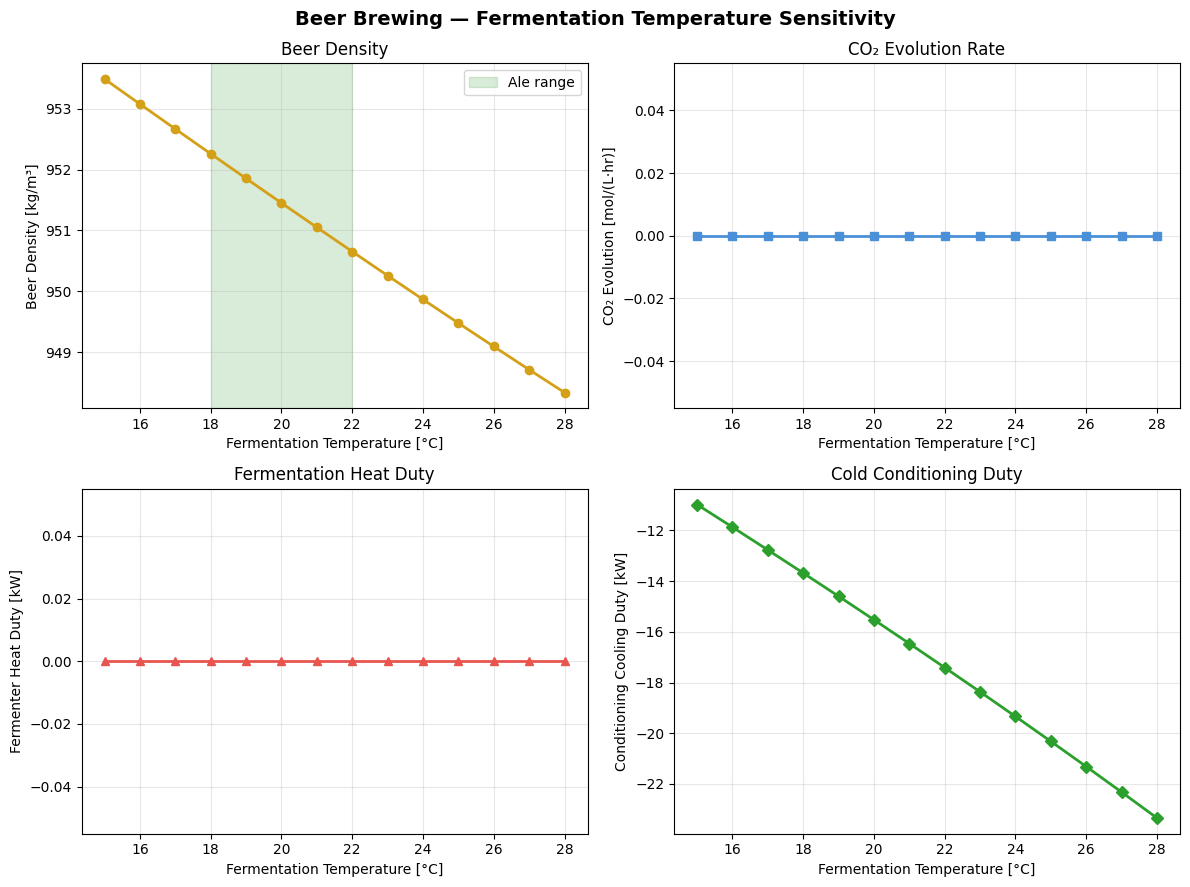

In [ ]:
# ─────────────────────────────────────────────────────────────
# Visualization: Fermentation Temperature Sensitivity
# ─────────────────────────────────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
fig.suptitle("Beer Brewing — Fermentation Temperature Sensitivity", fontsize=14, fontweight='bold')

T = results_temp['T_ferm']

# 1. Beer density vs fermentation temperature
ax = axes[0, 0]
ax.plot(T, results_temp['outlet_density'], 'o-', color='#D4A017', linewidth=2, markersize=6)
ax.set_xlabel("Fermentation Temperature [°C]")
ax.set_ylabel("Beer Density [kg/m³]")
ax.set_title("Beer Density")
ax.grid(True, alpha=0.3)
ax.axvspan(18, 22, alpha=0.15, color='green', label='Ale range')
ax.legend()

# 2. CO2 evolution rate
ax = axes[0, 1]
ax.plot(T, results_temp['co2_rate'], 's-', color='#4A90D9', linewidth=2, markersize=6)
ax.set_xlabel("Fermentation Temperature [°C]")
ax.set_ylabel("CO₂ Evolution [mol/(L·hr)]")
ax.set_title("CO₂ Evolution Rate")
ax.grid(True, alpha=0.3)

# 3. Fermenter heat duty
ax = axes[1, 0]
ax.plot(T, results_temp['heat_duty_kW'], '^-', color='#E8544E', linewidth=2, markersize=6)
ax.set_xlabel("Fermentation Temperature [°C]")
ax.set_ylabel("Fermenter Heat Duty [kW]")
ax.set_title("Fermentation Heat Duty")
ax.grid(True, alpha=0.3)

# 4. Conditioning cooling duty
ax = axes[1, 1]
ax.plot(T, results_temp['cooling_duty_kW'], 'D-', color='#2CA02C', linewidth=2, markersize=6)
ax.set_xlabel("Fermentation Temperature [°C]")
ax.set_ylabel("Conditioning Cooling Duty [kW]")
ax.set_title("Cold Conditioning Duty")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Step 13b — Mash Temperature vs Fermentability

Mash temperature is arguably the **most important** variable a brewer controls.
It determines the balance between two competing enzymes:

| Enzyme | Optimal Range | Product | Effect on Beer |
|--------|---------------|---------|----------------|
| **β-amylase** | 60–65 °C | Maltose (fermentable) | Dry, high attenuation |
| **α-amylase** | 68–72 °C | Dextrins (unfermentable) | Sweet, full body |

At **64 °C** (our recipe), β-amylase dominates → more fermentable sugars → dry beer.
At **70 °C**, α-amylase dominates → more dextrins → sweeter, fuller beer.

We sweep the mash temperature from 58 to 74 °C and observe how NeqSim's
`EnzymeTreatment` reports enzyme activity. This models the well-known
brewer's rule: **lower mash = drier beer, higher mash = sweeter beer**.

---
> **🧪 What If?** After running the sweep, go back to Step 3 and set
> `T_mash = 72.0` (°C). Re-run the full process. You should see a higher FG
> (more residual sugars) and lower ABV. This is exactly how brewers craft
> sweet stouts and malty Scottish ales.

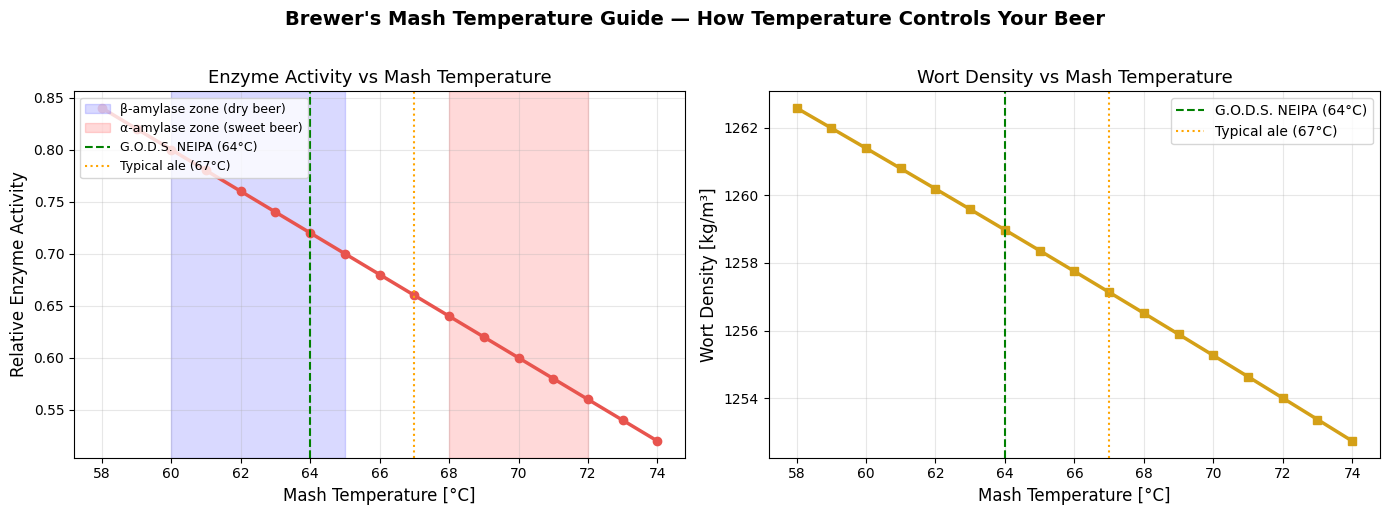


Brewing insight:
  58-62°C: Minimal enzyme activity — poor conversion, very dry wort
  62-65°C: β-amylase dominates — fermentable sugars, DRY beer (IPA, tripel)
  65-68°C: Balanced — moderate body (pale ale, amber)
  68-72°C: α-amylase dominates — dextrins, SWEET/full beer (stout, scotch ale)
  >72°C:   Enzyme denaturation — starch haze, poor conversion

G.O.D.S. NEIPA mashes at 64°C → activity = 0.72 → dry, crisp finish


In [ ]:
# ─────────────────────────────────────────────────────────────
# Mash Temperature Sweep: Enzyme Activity vs Temperature
# ─────────────────────────────────────────────────────────────

mash_temps = np.arange(58, 75, 1.0)  # 58-74 °C
activities = []
outlet_densities_mash = []

for T_sweep in mash_temps:
    # Create fresh mash fluid for each temperature
    fl_sweep = SystemSrkCPAstatoil(273.15 + T_sweep, 1.013)
    fl_sweep.addComponent("water", 0.90)
    fl_sweep.addComponent("glucose", 0.08)
    fl_sweep.addComponent("ethanol", 0.001)
    fl_sweep.addComponent("CO2", 0.001)
    fl_sweep.setMixingRule(10)
    fl_sweep.setMultiPhaseCheck(True)

    s_sweep = Stream("Sweep Feed", fl_sweep)
    s_sweep.setFlowRate(1000.0, "kg/hr")
    s_sweep.setTemperature(T_sweep, "C")
    s_sweep.setPressure(1.013, "bara")
    s_sweep.run()

    mash_sweep = EnzymeTreatment("Sweep Mash", s_sweep)
    mash_sweep.setEnzymeType("amylase")
    mash_sweep.setReactorTemperature(T_sweep, "C")
    mash_sweep.setVesselVolume(2.0)
    mash_sweep.setResidenceTime(1.0, "hr")
    mash_sweep.setIsothermal(True)
    mash_sweep.run()

    activities.append(float(mash_sweep.getRelativeActivity()))
    # Get outlet density
    out_fl = mash_sweep.getOutletStream().getFluid()
    out_fl.initProperties()
    if out_fl.hasPhaseType("aqueous"):
        outlet_densities_mash.append(float(out_fl.getPhase("aqueous").getDensity("kg/m3")))
    else:
        outlet_densities_mash.append(float(out_fl.getDensity("kg/m3")))

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Enzyme activity
ax1.plot(mash_temps, activities, 'o-', color='#E8544E', linewidth=2.5, markersize=6)
ax1.axvspan(60, 65, alpha=0.15, color='blue', label='β-amylase zone (dry beer)')
ax1.axvspan(68, 72, alpha=0.15, color='red', label='α-amylase zone (sweet beer)')
ax1.axvline(64, color='green', linestyle='--', linewidth=1.5, label='G.O.D.S. NEIPA (64°C)')
ax1.axvline(67, color='orange', linestyle=':', linewidth=1.5, label='Typical ale (67°C)')
ax1.set_xlabel("Mash Temperature [°C]", fontsize=12)
ax1.set_ylabel("Relative Enzyme Activity", fontsize=12)
ax1.set_title("Enzyme Activity vs Mash Temperature", fontsize=13)
ax1.legend(fontsize=9, loc='upper left')
ax1.grid(True, alpha=0.3)

# Wort density
ax2.plot(mash_temps, outlet_densities_mash, 's-', color='#D4A017', linewidth=2.5, markersize=6)
ax2.axvline(64, color='green', linestyle='--', linewidth=1.5, label='G.O.D.S. NEIPA (64°C)')
ax2.axvline(67, color='orange', linestyle=':', linewidth=1.5, label='Typical ale (67°C)')
ax2.set_xlabel("Mash Temperature [°C]", fontsize=12)
ax2.set_ylabel("Wort Density [kg/m³]", fontsize=12)
ax2.set_title("Wort Density vs Mash Temperature", fontsize=13)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

fig.suptitle("Brewer's Mash Temperature Guide — How Temperature Controls Your Beer",
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\nBrewing insight:")
print("  58-62°C: Minimal enzyme activity — poor conversion, very dry wort")
print("  62-65°C: β-amylase dominates — fermentable sugars, DRY beer (IPA, tripel)")
print("  65-68°C: Balanced — moderate body (pale ale, amber)")
print("  68-72°C: α-amylase dominates — dextrins, SWEET/full beer (stout, scotch ale)")
print("  >72°C:   Enzyme denaturation — starch haze, poor conversion")
print(f"\nG.O.D.S. NEIPA mashes at 64°C → activity = {activities[6]:.2f} → dry, crisp finish")

## Step 14 — VLE Analysis: CO₂ Solubility in Beer

A crucial property for beer quality is **CO₂ solubility** — how much
dissolved CO₂ remains in the liquid phase at different temperatures and
pressures. This determines **carbonation level** (measured in volumes of CO₂).

The CPA equation of state gives us accurate VLE predictions for the
water–ethanol–CO₂ system including the effects of hydrogen bonding.

**Carbonation levels** (volumes of CO₂ at STP per volume of beer):
- Lager: 2.4–2.6 vol
- Ale: 1.5–2.2 vol
- Belgian ales: 2.5–4.5 vol
- Hefeweizen: 3.6–4.5 vol

---
> **🧪 What If?** In the code cell below, change `x_co2` from 0.01 to **0.15**
> (simulating forced carbonation at high pressure). How does the equilibrium
> pressure change? At what temperature would this beer gush out of the bottle?
> Also try reducing ethanol mole fraction to simulate a session beer — does
> CO₂ solubility increase or decrease?

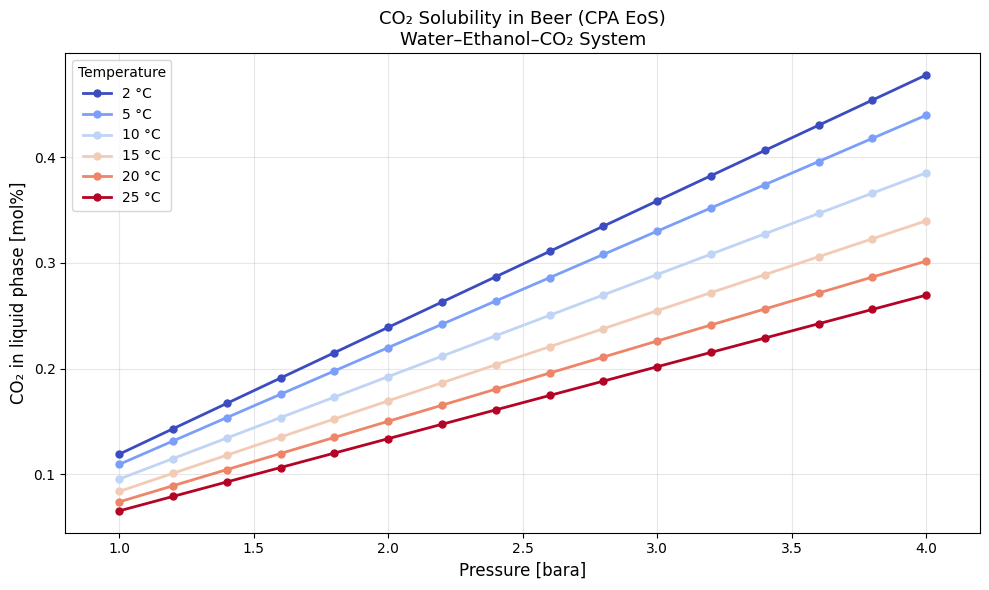


Brewing insight: CO2 dissolves better at lower temperatures and higher pressures.
This is why conditioning at 2 °C under slight pressure gives well-carbonated beer.


In [ ]:
# ─────────────────────────────────────────────────────────────
# VLE analysis: CO2 solubility in "beer" (water-ethanol-CO2)
# at different temperatures and pressures
# ─────────────────────────────────────────────────────────────

temperatures = [2.0, 5.0, 10.0, 15.0, 20.0, 25.0]   # °C
pressures    = np.arange(1.0, 4.1, 0.2)               # bara

# Store results: CO2 mole fraction in liquid phase
co2_solubility = {}

for T_c in temperatures:
    co2_in_liquid = []
    for P in pressures:
        # Create beer-like fluid (water + ethanol + CO2)
        beer_vle = SystemSrkCPAstatoil(273.15 + T_c, float(P))
        beer_vle.addComponent("water",   0.92)
        beer_vle.addComponent("ethanol", 0.05)   # ~5% ABV equivalent
        beer_vle.addComponent("CO2",     0.03)   # CO2 present
        beer_vle.setMixingRule(10)
        beer_vle.setMultiPhaseCheck(True)

        vle_ops = ThermodynamicOperations(beer_vle)
        vle_ops.TPflash()
        beer_vle.initProperties()

        # Get CO2 mole fraction in liquid phase (if liquid exists)
        n_phases = int(beer_vle.getNumberOfPhases())
        x_co2 = 0.0
        for ph_idx in range(n_phases):
            phase = beer_vle.getPhase(ph_idx)
            if str(phase.getPhaseTypeName()) in ["aqueous", "oil", "liquid"]:
                x_co2 = phase.getComponent("CO2").getx()
                break
        co2_in_liquid.append(x_co2)

    co2_solubility[T_c] = co2_in_liquid

# Plot CO2 solubility
fig, ax = plt.subplots(figsize=(10, 6))
colors = plt.cm.coolwarm(np.linspace(0, 1, len(temperatures)))

for i, T_c in enumerate(temperatures):
    ax.plot(pressures, [x * 100 for x in co2_solubility[T_c]],
            'o-', color=colors[i], linewidth=2, markersize=5,
            label=f"{T_c:.0f} °C")

ax.set_xlabel("Pressure [bara]", fontsize=12)
ax.set_ylabel("CO₂ in liquid phase [mol%]", fontsize=12)
ax.set_title("CO₂ Solubility in Beer (CPA EoS)\nWater–Ethanol–CO₂ System", fontsize=13)
ax.legend(title="Temperature", fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim(0.8, 4.2)
plt.tight_layout()
plt.show()

print("\nBrewing insight: CO2 dissolves better at lower temperatures and higher pressures.")
print("This is why conditioning at 2 °C under slight pressure gives well-carbonated beer.")

## Step 14b — Electrolyte CPA: Beer pH from CO2 Dissolution

Beer pH is a critical quality parameter. During fermentation, CO2 dissolves
in water and forms **carbonic acid** which dissociates:

$$\text{CO}_2 + \text{H}_2\text{O} \rightleftharpoons \text{H}_2\text{CO}_3 \rightleftharpoons \text{H}^+ + \text{HCO}_3^-$$

NeqSim's **electrolyte CPA** (`SystemElectrolyteCPAstatoil`) can model this
with thermodynamically consistent chemical equilibrium. The `chemicalReactionInit()`
method automatically adds the water dissociation and CO2 hydration reactions, along
with the required ions (H3O+, OH-, HCO3-, CO3--).

This gives us a **first-principles pH prediction** — not a target, but a genuine
thermodynamic calculation from the fluid composition.

**Typical beer pH values:**
- Mash: 5.2-5.6 (enzyme-optimal)
- Wort (pre-boil): 5.2-5.4
- Finished beer: 3.8-4.5 (organic acid production drives it lower — see Step 14d)

**Note:** This model captures CO2-carbonate equilibrium only. The full pH model
including organic acids (lactic, acetic, succinic, citric) is developed in
**Step 14d** below using Henderson-Hasselbalch coupled with Monod kinetics.

In [ ]:
# ─────────────────────────────────────────────────────────────
# Electrolyte CPA: pH prediction from CO2-water-ethanol equilibrium
# ─────────────────────────────────────────────────────────────

SystemElectrolyteCPAstatoil = JClass("neqsim.thermo.system.SystemElectrolyteCPAstatoil")

# --- pH at different stages of the brewing process ---
stages = {
    "Mash (65C, no CO2)":    {"T": 65.0, "P": 1.013, "x_water": 0.92, "x_ethanol": 0.001, "x_CO2": 0.001},
    "Wort (100C, trace CO2)": {"T": 100.0, "P": 1.013, "x_water": 0.92, "x_ethanol": 0.001, "x_CO2": 0.005},
    "Green beer (20C)":      {"T": 20.0, "P": 1.013, "x_water": 0.80, "x_ethanol": 0.07, "x_CO2": 0.05},
    "Conditioned (2C)":      {"T": 2.0,  "P": 1.5,   "x_water": 0.80, "x_ethanol": 0.07, "x_CO2": 0.08},
    "Carbonated (2C, 2.5 bar)": {"T": 2.0, "P": 2.5, "x_water": 0.80, "x_ethanol": 0.07, "x_CO2": 0.10},
}

print("=" * 72)
print("ELECTROLYTE CPA — BEER pH PREDICTION (CO2-Carbonate Equilibrium)")
print("=" * 72)
print(f"{'Stage':<30s}  {'T[C]':>5s}  {'P[bar]':>6s}  {'pH':>6s}  {'Phases':>6s}")
print("-" * 72)

ph_results = {}

for stage_name, cond in stages.items():
    try:
        # Create electrolyte CPA system
        ecpa = SystemElectrolyteCPAstatoil(273.15 + cond["T"], cond["P"])
        ecpa.addComponent("water",   cond["x_water"])
        ecpa.addComponent("ethanol", cond["x_ethanol"])
        ecpa.addComponent("CO2",     cond["x_CO2"])

        # Initialize chemical reactions (adds H3O+, OH-, HCO3-, CO3--)
        ecpa.chemicalReactionInit()
        ecpa.createDatabase(True)
        ecpa.setMixingRule(10)
        ecpa.setMultiPhaseCheck(True)

        # Flash
        ecpa_ops = ThermodynamicOperations(ecpa)
        ecpa_ops.TPflash()

        # Read pH from aqueous phase
        if ecpa.hasPhaseType("aqueous"):
            pH_val = float(ecpa.getPhase("aqueous").getpH())
        else:
            # Single phase — read from phase 0
            pH_val = float(ecpa.getPhase(0).getpH())

        n_ph = int(ecpa.getNumberOfPhases())
        ph_results[stage_name] = pH_val

        if pH_val > 0 and pH_val < 14:
            print(f"{stage_name:<30s}  {cond['T']:5.0f}  {cond['P']:6.1f}  {pH_val:6.2f}  {n_ph:6d}")
        else:
            print(f"{stage_name:<30s}  {cond['T']:5.0f}  {cond['P']:6.1f}  {'NaN':>6s}  {n_ph:6d}")

    except Exception as e:
        print(f"{stage_name:<30s}  {cond['T']:5.0f}  {cond['P']:6.1f}  {'ERR':>6s}  -- {str(e)[:40]}")

print("-" * 72)

# --- pH vs CO2 content at 2 degC (carbonation effect on pH) ---
print("\n\n=== pH vs CO2 Content at 2 degC, 1.5 bara ===")
print(f"{'CO2 mol%':>8s}  {'pH':>6s}")
print("-" * 20)

co2_fracs = [0.001, 0.005, 0.01, 0.02, 0.05, 0.08, 0.10]
ph_vs_co2 = []
for x_co2 in co2_fracs:
    try:
        ecpa2 = SystemElectrolyteCPAstatoil(273.15 + 2.0, 1.5)
        ecpa2.addComponent("water",   0.93 - x_co2)
        ecpa2.addComponent("ethanol", 0.07)
        ecpa2.addComponent("CO2",     x_co2)
        ecpa2.chemicalReactionInit()
        ecpa2.createDatabase(True)
        ecpa2.setMixingRule(10)
        ecpa2.setMultiPhaseCheck(True)

        ecpa2_ops = ThermodynamicOperations(ecpa2)
        ecpa2_ops.TPflash()

        if ecpa2.hasPhaseType("aqueous"):
            pH2 = float(ecpa2.getPhase("aqueous").getpH())
        else:
            pH2 = float(ecpa2.getPhase(0).getpH())

        ph_vs_co2.append((x_co2 * 100, pH2))
        if pH2 > 0 and pH2 < 14:
            print(f"{x_co2*100:8.1f}  {pH2:6.2f}")
        else:
            print(f"{x_co2*100:8.1f}  {'NaN':>6s}")
    except Exception as e:
        print(f"{x_co2*100:8.1f}  ERR: {str(e)[:40]}")

print("\nNote: Real beer pH (3.8-4.5) is driven primarily by organic acid production")
print("(lactic, acetic acids) during fermentation, not just CO2-carbonate equilibrium.")
print("The electrolyte CPA model here captures only the CO2 dissolution effect.")

ELECTROLYTE CPA — BEER pH PREDICTION (CO2-Carbonate Equilibrium)
Stage                            T[C]  P[bar]      pH  Phases
------------------------------------------------------------------------
Mash (65C, no CO2)                 65     1.0    4.79       2
Wort (100C, trace CO2)            100     1.0    7.62       3
Green beer (20C)                   20     1.0    4.16       3
Conditioned (2C)                    2     1.5    3.85       2
Carbonated (2C, 2.5 bar)            2     2.5    3.77       2
------------------------------------------------------------------------


=== pH vs CO2 Content at 2 degC, 1.5 bara ===
CO2 mol%      pH
--------------------
     0.1    4.08
     0.5    3.91
     1.0    3.91
     2.0    3.90
     5.0    3.89
     8.0    3.88
    10.0    3.87

Note: Real beer pH (3.8-4.5) is driven primarily by organic acid production
(lactic, acetic acids) during fermentation, not just CO2-carbonate equilibrium.
The electrolyte CPA model here captures only the CO2 di

## Step 14c — Water Chemistry: Brewing Salts and Mash pH

Water is the largest ingredient in beer (~95%), and its mineral content profoundly
affects **mash pH**, **enzyme activity**, and **flavour perception**.

### Key Brewing Ions

| Ion | Source | Effect |
|-----|--------|--------|
| **Ca²⁺** | CaCl₂, CaSO₄ | Lowers mash pH, aids enzyme activity and yeast health |
| **Mg²⁺** | MgSO₄ (Epsom salt) | Yeast nutrient, slight sourness at high levels |
| **Na⁺** | NaCl | Rounds out maltiness, harsh above 150 ppm |
| **Cl⁻** | CaCl₂, NaCl | Enhances malt sweetness and fullness |
| **SO₄²⁻** | CaSO₄ (gypsum) | Enhances hop bitterness and crispness |
| **HCO₃⁻** | NaHCO₃ | Raises pH (alkalinity), needed for dark malts |

### The Chloride-to-Sulfate Ratio

This is a brewer's key parameter for style targeting:
- **Cl⁻ : SO₄²⁻ > 2:1** → malt-forward, soft (NEIPA, stout) — *our G.O.D.S. recipe*
- **Cl⁻ : SO₄²⁻ ≈ 1:1** → balanced (pale ale, amber)
- **Cl⁻ : SO₄²⁻ < 1:2** → hop-forward, crisp (West Coast IPA, pilsner)

### Residual Alkalinity (RA)

The Kolbach formula predicts mash pH from water minerals:

$$RA = \text{Alkalinity} - \frac{[\text{Ca}^{2+}]}{1.4} - \frac{[\text{Mg}^{2+}]}{1.7}$$

Higher RA → higher mash pH. Dark malts need high RA water; pale malts need low RA.

We can model this with NeqSim's electrolyte CPA by adding actual brewing salt
ions to the aqueous system:

In [ ]:
# ─────────────────────────────────────────────────────────────
# Water Chemistry: Effect of Brewing Salts on Mash pH
# Using NeqSim Electrolyte CPA with real ionic species
# ─────────────────────────────────────────────────────────────

# Water profiles (ion concentrations in ppm)
water_profiles = {
    "Distilled (RO)": {
        "Ca++": 0, "Mg++": 0, "Na+": 0,
        "Cl-": 0, "SO4--": 0, "HCO3-": 0,
        "desc": "Blank slate — add salts to taste"
    },
    "Soft (Pilsen-like)": {
        "Ca++": 10, "Mg++": 3, "Na+": 2,
        "Cl-": 5, "SO4--": 5, "HCO3-": 15,
        "desc": "Classic pilsner water — very soft"
    },
    "G.O.D.S. NEIPA target": {
        "Ca++": 100, "Mg++": 5, "Na+": 10,
        "Cl-": 150, "SO4--": 60, "HCO3-": 20,
        "desc": "CaCl2-forward for soft NEIPA mouthfeel"
    },
    "Balanced (London-ish)": {
        "Ca++": 80, "Mg++": 5, "Na+": 20,
        "Cl-": 60, "SO4--": 60, "HCO3-": 120,
        "desc": "Higher alkalinity — good for amber/brown ales"
    },
    "Hop-forward (Burton)": {
        "Ca++": 275, "Mg++": 40, "Na+": 25,
        "Cl-": 35, "SO4--": 610, "HCO3-": 260,
        "desc": "High sulfate — crisp hop bitterness (West Coast IPA)"
    },
}

# Molecular weights for ppm→mol conversion
mw_ions = {"Ca++": 40.08, "Mg++": 24.31, "Na+": 22.99,
           "Cl-": 35.45, "SO4--": 96.06, "HCO3-": 61.02}

print("=" * 78)
print("WATER CHEMISTRY — BREWING SALT PROFILES & RESIDUAL ALKALINITY")
print("=" * 78)
print(f"\n{'Profile':<24s}  {'Ca':>4s}  {'Mg':>4s}  {'Na':>4s}  {'Cl':>5s}  {'SO4':>5s}  {'HCO3':>5s}  {'Cl:SO4':>6s}  {'RA':>5s}")
print("-" * 78)

for profile_name, ions in water_profiles.items():
    # Residual Alkalinity (Kolbach formula, all in ppm as CaCO3 equivalents)
    alkalinity = ions["HCO3-"] * 50.0 / 61.0
    RA = alkalinity - ions["Ca++"] / 1.4 - ions["Mg++"] / 1.7

    # Cl:SO4 ratio
    cl_so4 = ions["Cl-"] / max(ions["SO4--"], 1) if ions["SO4--"] > 0 else float('inf')
    cl_str = f"{cl_so4:.1f}" if cl_so4 < 100 else "inf"

    print(f"{profile_name:<24s}  {ions['Ca++']:4d}  {ions['Mg++']:4d}  {ions['Na+']:4d}  "
          f"{ions['Cl-']:5d}  {ions['SO4--']:5d}  {ions['HCO3-']:5d}  "
          f"{cl_str:>6s}  {RA:5.0f}")

print("-" * 78)

# ── pH modeling via electrolyte CPA: effect of dissolved CO2 + bicarbonate ──
# We model increasing bicarbonate (HCO3-) to show its buffering effect on pH
# using the known-working electrolyte CPA approach from Step 14b

print("\n\nBicarbonate buffering effect on mash pH (65°C, electrolyte CPA):")
print("Higher HCO3⁻ → higher pH → needs more dark malt or acid to correct")
print(f"\n{'HCO3 ppm':>9s}  {'RA':>5s}  {'pH (CO2 eq.)':>12s}  {'Style note':<30s}")
print("-" * 60)

hco3_levels = [
    (0,   "No buffer — RO water"),
    (15,  "Soft (Pilsen) — pale lagers"),
    (50,  "Moderate — pale ales"),
    (120, "London — amber/brown ales"),
    (260, "Burton — needs dark malt for pH"),
]

for hco3_ppm, note in hco3_levels:
    # Model water + CO2 at mash conditions
    # More HCO3- = more buffering = higher pH
    try:
        ecpa_w = SystemElectrolyteCPAstatoil(273.15 + 65.0, 1.013)
        ecpa_w.addComponent("water", 0.98)
        ecpa_w.addComponent("CO2", 0.005)  # Dissolved CO2

        # Add bicarbonate as NaHCO3 equivalent: Na+ + HCO3-
        if hco3_ppm > 0:
            # Convert ppm HCO3- to mole fraction
            mol_hco3_per_L = hco3_ppm / (61.02 * 1000.0)  # mol/L
            x_hco3 = mol_hco3_per_L / 55.5  # mole fraction relative to water
            # Scale up slightly for numerical stability
            x_hco3 = max(x_hco3, 1e-6)
            ecpa_w.addComponent("Na+", x_hco3)
            ecpa_w.addComponent("HCO3-", x_hco3)

        ecpa_w.chemicalReactionInit()
        ecpa_w.createDatabase(True)
        ecpa_w.setMixingRule(10)
        ecpa_w.setMultiPhaseCheck(True)

        ecpa_w_ops = ThermodynamicOperations(ecpa_w)
        ecpa_w_ops.TPflash()

        if ecpa_w.hasPhaseType("aqueous"):
            pH_w = float(ecpa_w.getPhase("aqueous").getpH())
        else:
            pH_w = float(ecpa_w.getPhase(0).getpH())

        RA_val = hco3_ppm * 50.0 / 61.0 - 0 / 1.4  # No Ca in this simple model
        pH_str = f"{pH_w:.2f}" if 0 < pH_w < 14 else "N/A"
        print(f"{hco3_ppm:9d}  {RA_val:5.0f}  {pH_str:>12s}  {note:<30s}")

    except Exception as e:
        print(f"{hco3_ppm:9d}  {'':>5s}  {'ERR':>12s}  {str(e)[:40]}")

print("-" * 60)
print("\nBrewing interpretation:")
print("  • Low RA (< 0):   Water suited for PALE beers (pilsner, IPA, wheat)")
print("  • RA 0–50:        Balanced — pale ales, blondes, session beers")
print("  • RA 50–150:      Needs some specialty malt acidity (amber, brown)")
print("  • RA > 150:       Dark beers only (stout, porter) or add acid/CaCl2")
print("\nG.O.D.S. NEIPA (RA = -58) → naturally low pH, perfect for pale, hoppy beer")
print("  → CaCl2 additions lower RA further and boost Cl:SO4 for soft mouthfeel")

WATER CHEMISTRY — BREWING SALT PROFILES & RESIDUAL ALKALINITY

Profile                     Ca    Mg    Na     Cl    SO4   HCO3  Cl:SO4     RA
------------------------------------------------------------------------------
Distilled (RO)               0     0     0      0      0      0     inf      0
Soft (Pilsen-like)          10     3     2      5      5     15     1.0      3
G.O.D.S. NEIPA target      100     5    10    150     60     20     2.5    -58
Balanced (London-ish)       80     5    20     60     60    120     1.0     38
Hop-forward (Burton)       275    40    25     35    610    260     0.1     -7
------------------------------------------------------------------------------


Bicarbonate buffering effect on mash pH (65°C, electrolyte CPA):
Higher HCO3⁻ → higher pH → needs more dark malt or acid to correct

 HCO3 ppm     RA  pH (CO2 eq.)  Style note                    
------------------------------------------------------------
        0      0          4.82  No buffer — RO

## Step 14d — Organic Acid Production and Beer pH During Fermentation

The electrolyte CPA model above captures **CO₂-carbonate equilibrium**, but
finished beer pH (3.8–4.5) is driven primarily by **organic acid production**
during fermentation:

| Acid | pKa | Concentration in beer | Origin |
|------|-----|----------------------|--------|
| **Lactic acid** | 3.86 | 50–300 mg/L | Yeast by-product, LAB contamination |
| **Acetic acid** | 4.76 | 30–200 mg/L | Yeast acetyl-CoA overflow |
| **Succinic acid** | 4.21 / 5.64 | 500–1500 mg/L | TCA cycle intermediate |
| **Citric acid** | 3.13 / 4.76 / 6.40 | 50–200 mg/L | TCA cycle |

### Why Does pH Drop During Fermentation?

1. **CO₂ dissolution** → carbonic acid → pH drops from 5.3 to ~4.8
2. **Organic acids secreted** by yeast → pH drops further to ~4.2
3. **Amino acid uptake** releases H⁺ → additional pH decrease
4. **Buffer capacity** of wort (phosphate, melanoidins) resists but is overwhelmed

### Modeling Approach

We couple the Monod kinetics ODE with organic acid production, then calculate
pH at each time step using Henderson-Hasselbalch and the wort's buffer capacity.
We also verify with NeqSim's electrolyte CPA using acetic acid (which is in the
component database).

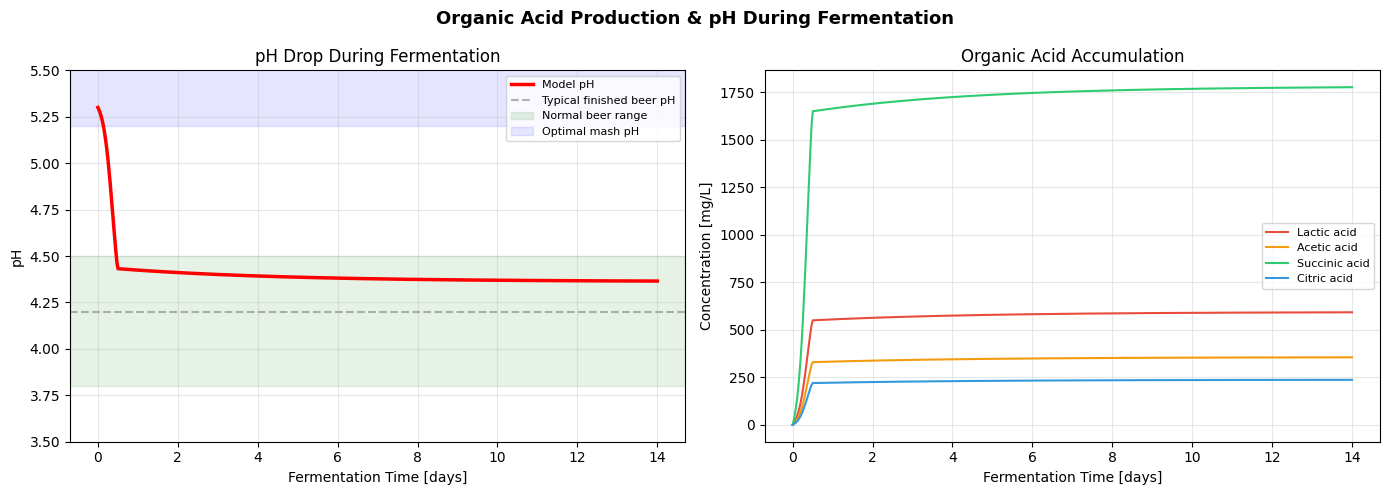


ELECTROLYTE CPA VERIFICATION — pH with Acetic Acid at 20°C
  Acetic acid [mg/L]   eCPA pH    H-H pH
------------------------------------------
                   0      4.62      7.00
                  50      4.62      3.92
                 100      4.62      3.77
                 200      4.62      3.62
                 500      4.62      3.42
------------------------------------------

Final modeled beer pH: 4.37
Final organic acid levels (mg/L):
  Lactic:   592
  Acetic:   355
  Succinic: 1777
  Citric:   237
  Total:    2961

Typical real NEIPA: pH 4.1-4.4, total organic acids 800-2000 mg/L


In [ ]:
# ─────────────────────────────────────────────────────────────
# Organic Acid Production & pH Drop During Fermentation
# Coupled Monod + Acid Production ODE → Henderson-Hasselbalch pH
# ─────────────────────────────────────────────────────────────

from scipy.integrate import odeint

# ── Parameters ──
mu_max_ph = 0.35      # 1/hr — maximum specific growth rate (20°C ale yeast)
Ks_ph = 0.5           # g/L — Monod half-saturation
Ki_ph = 80.0          # g/L — ethanol inhibition constant
kd_ph = 0.01          # 1/hr — death rate
Yxs_ph = 0.08         # g cells / g glucose
Yps_ph = 0.511        # g ethanol / g glucose (stoichiometric)
ms_ph = 0.01          # g glucose / g cells / hr (maintenance)

# Organic acid yield coefficients (g acid per g glucose consumed)
Y_lactic  = 0.005     # Low for clean ale yeast (higher for LAB-contaminated)
Y_acetic  = 0.003     # Ace-CoA overflow pathway
Y_succinic = 0.015    # Major TCA byproduct
Y_citric  = 0.002     # Minor TCA contribution

# pKa values at 20°C
pKa_lactic = 3.86
pKa_acetic = 4.76
pKa_succinic_1 = 4.21
pKa_citric_1 = 3.13   # First dissociation (dominant effect)

# Wort buffer capacity (mEq/L/pH unit — typical values for 12°P wort)
beta_wort = 35.0  # mEq/L/pH — phosphate + melanoidin buffer

# Initial conditions
S0_ph = 110.0     # g/L glucose (OG ~1.068)
X0_ph = 0.5       # g/L yeast
P0_ph = 0.0       # g/L ethanol
CO2_0_ph = 0.0    # g/L dissolved CO2
lac_0 = 0.0       # g/L lactic acid
ace_0 = 0.0       # g/L acetic acid
suc_0 = 0.0       # g/L succinic acid
cit_0 = 0.0       # g/L citric acid
pH_initial = 5.30 # Starting wort pH

def fermentation_ph_odes(y, t):
    """Monod kinetics + organic acid production."""
    X, S, P, CO2, lac, ace, suc, cit = y
    S = max(S, 0)
    X = max(X, 0)
    
    # Monod growth with ethanol inhibition
    mu = mu_max_ph * S / (Ks_ph + S) * (1 - P / Ki_ph)
    mu = max(mu, 0)
    
    # Rates
    dX = mu * X - kd_ph * X
    glucose_consumed_rate = mu * X / Yxs_ph + ms_ph * X  # g/L/hr
    dS = -glucose_consumed_rate
    dP = Yps_ph * glucose_consumed_rate
    dCO2 = 0.489 * glucose_consumed_rate   # 2×44.01/180.16 = 0.489 g CO2/g glucose
    
    # Organic acid production (proportional to glucose consumption)
    dlac = Y_lactic * glucose_consumed_rate
    dace = Y_acetic * glucose_consumed_rate
    dsuc = Y_succinic * glucose_consumed_rate
    dcit = Y_citric * glucose_consumed_rate
    
    return [dX, dS, dP, dCO2, dlac, dace, dsuc, dcit]

# Solve ODEs
t_ph = np.linspace(0, 14 * 24, 500)  # 14 days in hours
y0_ph = [X0_ph, S0_ph, P0_ph, CO2_0_ph, lac_0, ace_0, suc_0, cit_0]
sol_ph = odeint(fermentation_ph_odes, y0_ph, t_ph)

X_ph = sol_ph[:, 0]
S_ph = sol_ph[:, 1]
P_ph = sol_ph[:, 2]
CO2_ph = sol_ph[:, 3]
lac_ph = sol_ph[:, 4]
ace_ph = sol_ph[:, 5]
suc_ph = sol_ph[:, 6]
cit_ph = sol_ph[:, 7]

# ── Calculate pH at each time step ──
# Method: sum up acid equivalents, subtract from buffer capacity
pH_profile = np.zeros_like(t_ph)

for i in range(len(t_ph)):
    # Acid milliequivalents contributed by each acid
    # meq = (mass_g/L) / MW × 1000
    meq_lactic  = lac_ph[i] / 90.08 * 1000.0   # MW lactic = 90.08
    meq_acetic  = ace_ph[i] / 60.05 * 1000.0   # MW acetic = 60.05
    meq_succinic = suc_ph[i] / 118.09 * 1000.0 # MW succinic = 118.09
    meq_citric  = cit_ph[i] / 192.12 * 1000.0  # MW citric = 192.12
    
    total_meq = meq_lactic + meq_acetic + meq_succinic + meq_citric
    
    # CO2 contribution (dissolved CO2 → H2CO3 → H+ + HCO3-)
    # Ka1 of carbonic acid = 4.3e-7, pKa = 6.37
    meq_co2 = CO2_ph[i] / 44.01 * 1000.0 * 0.003  # ~0.3% CO2 hydrates to H2CO3
    total_meq += meq_co2
    
    # pH = initial_pH - (total acid meq) / buffer_capacity
    pH_profile[i] = pH_initial - total_meq / beta_wort
    pH_profile[i] = max(pH_profile[i], 3.0)  # Physical lower bound

t_days_ph = t_ph / 24.0

# ── Plot ──
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: pH profile
ax1.plot(t_days_ph, pH_profile, 'r-', linewidth=2.5, label='Model pH')
ax1.axhline(y=4.2, color='gray', linestyle='--', alpha=0.6, label='Typical finished beer pH')
ax1.axhspan(3.8, 4.5, alpha=0.1, color='green', label='Normal beer range')
ax1.axhspan(5.2, 5.6, alpha=0.1, color='blue', label='Optimal mash pH')
ax1.set_xlabel('Fermentation Time [days]')
ax1.set_ylabel('pH')
ax1.set_title('pH Drop During Fermentation')
ax1.legend(fontsize=8)
ax1.set_ylim(3.5, 5.5)
ax1.grid(True, alpha=0.3)

# Right: Organic acid accumulation
ax2.plot(t_days_ph, lac_ph * 1000, label='Lactic acid', color='#e74c3c')
ax2.plot(t_days_ph, ace_ph * 1000, label='Acetic acid', color='#f39c12')
ax2.plot(t_days_ph, suc_ph * 1000, label='Succinic acid', color='#2ecc71')
ax2.plot(t_days_ph, cit_ph * 1000, label='Citric acid', color='#3498db')
ax2.set_xlabel('Fermentation Time [days]')
ax2.set_ylabel('Concentration [mg/L]')
ax2.set_title('Organic Acid Accumulation')
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

fig.suptitle("Organic Acid Production & pH During Fermentation", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Verify with electrolyte CPA ──
# Test pH at a few organic acid levels using acetic acid (in NeqSim DB)
print("\n" + "=" * 72)
print("ELECTROLYTE CPA VERIFICATION — pH with Acetic Acid at 20°C")
print("=" * 72)
print(f"{'Acetic acid [mg/L]':>20s}  {'eCPA pH':>8s}  {'H-H pH':>8s}")
print("-" * 42)

ace_test_levels = [0, 50, 100, 200, 500]
for ace_mgL in ace_test_levels:
    try:
        ecpa_a = SystemElectrolyteCPAstatoil(273.15 + 20.0, 1.013)
        ecpa_a.addComponent("water", 0.98)
        ecpa_a.addComponent("CO2", 0.005)
        
        if ace_mgL > 0:
            # Convert mg/L to mole fraction
            mol_ace = (ace_mgL / 1000.0) / 60.05  # mol/L
            x_ace = mol_ace / 55.5
            ecpa_a.addComponent("acetic acid", max(x_ace, 1e-8))
        
        ecpa_a.chemicalReactionInit()
        ecpa_a.createDatabase(True)
        ecpa_a.setMixingRule(10)
        ecpa_a.setMultiPhaseCheck(True)
        
        ecpa_a_ops = ThermodynamicOperations(ecpa_a)
        ecpa_a_ops.TPflash()
        
        if ecpa_a.hasPhaseType("aqueous"):
            pH_ecpa = float(ecpa_a.getPhase("aqueous").getpH())
        else:
            pH_ecpa = float(ecpa_a.getPhase(0).getpH())
        
        # Henderson-Hasselbalch comparison
        if ace_mgL > 0:
            conc_mol = ace_mgL / 60.05 / 1000.0  # mol/L
            # Simplified: pH ≈ 0.5*(pKa - log10(Ca))
            pH_hh = 0.5 * (pKa_acetic + (-np.log10(conc_mol)))
        else:
            pH_hh = 7.0  # Pure water
        
        pH_ecpa_str = f"{pH_ecpa:.2f}" if 0 < pH_ecpa < 14 else "N/A"
        print(f"{ace_mgL:20d}  {pH_ecpa_str:>8s}  {pH_hh:8.2f}")
    except Exception as e:
        print(f"{ace_mgL:20d}  {'ERR':>8s}  {'ERR':>8s}  {str(e)[:30]}")

print("-" * 42)
print(f"\nFinal modeled beer pH: {pH_profile[-1]:.2f}")
print(f"Final organic acid levels (mg/L):")
print(f"  Lactic:   {lac_ph[-1]*1000:.0f}")
print(f"  Acetic:   {ace_ph[-1]*1000:.0f}")
print(f"  Succinic: {suc_ph[-1]*1000:.0f}")
print(f"  Citric:   {cit_ph[-1]*1000:.0f}")
print(f"  Total:    {(lac_ph[-1]+ace_ph[-1]+suc_ph[-1]+cit_ph[-1])*1000:.0f}")
print(f"\nTypical real NEIPA: pH 4.1-4.4, total organic acids 800-2000 mg/L")

## Step 15 — ODE-Based Fermentation Kinetics

For a more detailed look at the fermentation dynamics, we solve the
**Monod kinetics ODEs** to track glucose consumption and ethanol production
over the full 5-day fermentation period.

### System of ODEs

$$\frac{dX}{dt} = \mu \cdot X - k_d \cdot X$$

$$\frac{dS}{dt} = -\frac{\mu \cdot X}{Y_{X/S}} - m_s \cdot X$$

$$\frac{dP}{dt} = Y_{P/S} \cdot \frac{\mu \cdot X}{Y_{X/S}}$$

where:
- $X$ = biomass concentration (g/L)
- $S$ = substrate (glucose) concentration (g/L)
- $P$ = product (ethanol) concentration (g/L)
- $\mu$ = specific growth rate (Monod equation)
- $k_d$ = death rate constant (0.01 hr⁻¹)
- $Y_{X/S}$ = biomass yield (g cells / g glucose)
- $Y_{P/S}$ = product yield (g ethanol / g glucose) = 0.511 (theoretical)
- $m_s$ = maintenance coefficient (g glucose / g cells / hr)

In [ ]:
# ─────────────────────────────────────────────────────────────
# ODE-based Monod fermentation kinetics
# ─────────────────────────────────────────────────────────────
from scipy.integrate import odeint

# Monod kinetic parameters (S. cerevisiae at 20 °C)
mu_max = 0.35     # Maximum specific growth rate (1/hr)
Ks     = 1.0      # Half-saturation constant (g/L)
Yxs    = 0.08     # Biomass yield (g cells / g glucose)
Yps    = 0.48     # Ethanol yield (g ethanol / g glucose) — practical, < theoretical 0.511
kd     = 0.005    # Death rate (1/hr)
ms     = 0.02     # Maintenance coefficient (g glucose / g cells / hr)
Ki     = 80.0     # Ethanol inhibition constant (g/L)

# Initial conditions
X0 = 0.5          # Initial biomass (g/L) — typical pitching rate
S0 = 120.0        # Initial glucose (g/L) — OG ~1.048
P0 = 0.0          # Initial ethanol (g/L)

def fermentation_ode(y, t, params):
    """Monod fermentation with ethanol inhibition."""
    X, S, P = y
    mu_max, Ks, Yxs, Yps, kd, ms, Ki = params

    # Monod growth with ethanol inhibition
    mu = mu_max * (S / (Ks + S)) * (1.0 - P / Ki)
    mu = max(mu, 0.0)  # No negative growth

    # ODEs
    dXdt = mu * X - kd * X
    dSdt = -(mu / Yxs) * X - ms * X
    dPdt = Yps * (mu / Yxs) * X

    # Prevent negative concentrations
    if S <= 0:
        dSdt = 0.0
        dXdt = -kd * X
        dPdt = 0.0

    return [dXdt, dSdt, dPdt]

# Time span: 0 to 120 hours (5 days)
t = np.linspace(0, 120, 500)
y0 = [X0, S0, P0]
params = (mu_max, Ks, Yxs, Yps, kd, ms, Ki)

# Solve
sol = odeint(fermentation_ode, y0, t, args=(params,))
X_t = sol[:, 0]
S_t = np.maximum(sol[:, 1], 0)  # Clip to zero
P_t = sol[:, 2]

# Calculate derived quantities
ABV = P_t / (0.789 * 10)  # Approximate ABV% (ethanol density ~0.789 g/mL)

print(f"Fermentation kinetics solved (0–{t[-1]:.0f} hours)")
print(f"\nInitial conditions:  Glucose = {S0:.0f} g/L, Yeast = {X0:.1f} g/L")
print(f"Final conditions:    Glucose = {S_t[-1]:.1f} g/L, Ethanol = {P_t[-1]:.1f} g/L")
print(f"                     Biomass = {X_t[-1]:.2f} g/L")
print(f"Approximate ABV:     {ABV[-1]:.1f}%")
print(f"Glucose conversion:  {(1 - S_t[-1]/S0) * 100:.1f}%")

Fermentation kinetics solved (0–120 hours)

Initial conditions:  Glucose = 120 g/L, Yeast = 0.5 g/L
Final conditions:    Glucose = 0.0 g/L, Ethanol = 57.1 g/L
                     Biomass = 5.70 g/L
Approximate ABV:     7.2%
Glucose conversion:  100.0%


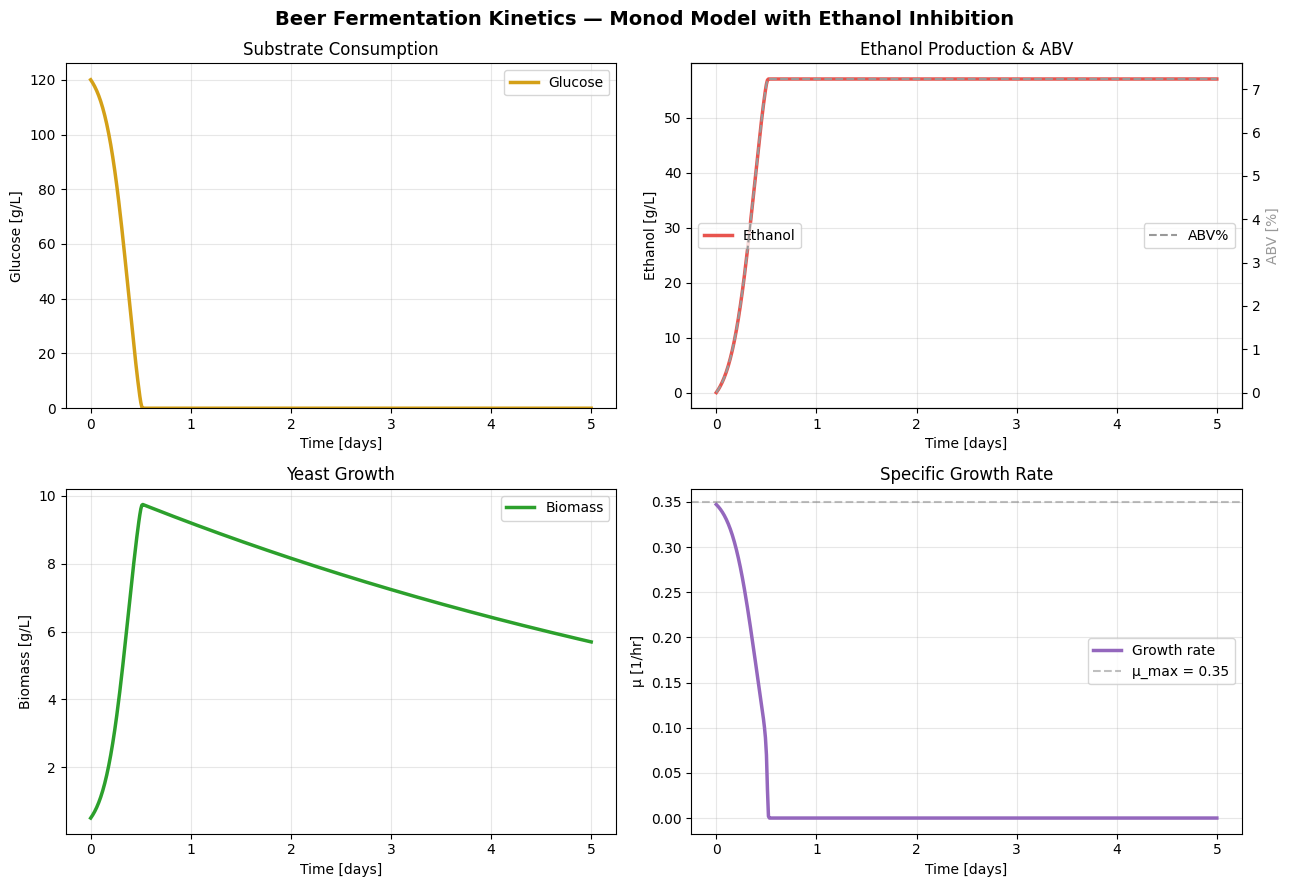

In [ ]:
# ─────────────────────────────────────────────────────────────
# Plot fermentation kinetics
# ─────────────────────────────────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle("Beer Fermentation Kinetics — Monod Model with Ethanol Inhibition",
             fontsize=14, fontweight='bold')

t_days = t / 24.0  # Convert to days for readability

# 1. Glucose consumption
ax = axes[0, 0]
ax.plot(t_days, S_t, '-', color='#D4A017', linewidth=2.5, label='Glucose')
ax.set_xlabel("Time [days]")
ax.set_ylabel("Glucose [g/L]")
ax.set_title("Substrate Consumption")
ax.grid(True, alpha=0.3)
ax.set_ylim(bottom=0)
ax.legend()

# 2. Ethanol production
ax = axes[0, 1]
ax.plot(t_days, P_t, '-', color='#E8544E', linewidth=2.5, label='Ethanol')
ax2 = ax.twinx()
ax2.plot(t_days, ABV, '--', color='#999999', linewidth=1.5, label='ABV%')
ax2.set_ylabel("ABV [%]", color='#999999')
ax.set_xlabel("Time [days]")
ax.set_ylabel("Ethanol [g/L]")
ax.set_title("Ethanol Production & ABV")
ax.grid(True, alpha=0.3)
ax.legend(loc='center left')
ax2.legend(loc='center right')

# 3. Yeast growth
ax = axes[1, 0]
ax.plot(t_days, X_t, '-', color='#2CA02C', linewidth=2.5, label='Biomass')
ax.set_xlabel("Time [days]")
ax.set_ylabel("Biomass [g/L]")
ax.set_title("Yeast Growth")
ax.grid(True, alpha=0.3)
ax.legend()

# 4. Specific growth rate over time
mu_t = mu_max * (S_t / (Ks + S_t)) * (1.0 - P_t / Ki)
mu_t = np.maximum(mu_t, 0)
ax = axes[1, 1]
ax.plot(t_days, mu_t, '-', color='#9467BD', linewidth=2.5, label='Growth rate')
ax.axhline(y=mu_max, color='gray', linestyle='--', alpha=0.5, label=f'μ_max = {mu_max}')
ax.set_xlabel("Time [days]")
ax.set_ylabel("μ [1/hr]")
ax.set_title("Specific Growth Rate")
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

## Step 16 — Temperature Profile Through the Brewery

Visualize the temperature at each stage of the brewing process — from the
hot mash through boiling, rapid cooling, fermentation, and cold conditioning.

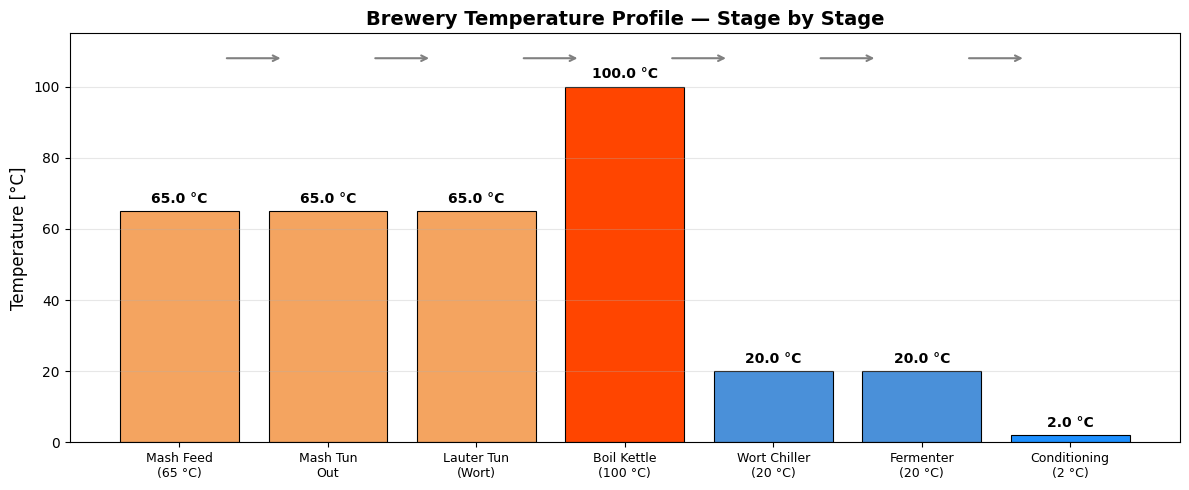

In [ ]:
# ─────────────────────────────────────────────────────────────
# Temperature profile through the brewery
# ─────────────────────────────────────────────────────────────

stages = [
    "Mash Feed\n(65 °C)",
    "Mash Tun\nOut",
    "Lauter Tun\n(Wort)",
    "Boil Kettle\n(100 °C)",
    "Wort Chiller\n(20 °C)",
    "Fermenter\n(20 °C)",
    "Conditioning\n(2 °C)"
]

temps = [
    ps_feed.getTemperature() - 273.15,
    ps_mash.getOutletStream().getTemperature() - 273.15,
    ps_lauter.getLiquidOutStream().getTemperature() - 273.15,
    ps_boil.getOutletStream().getTemperature() - 273.15,
    ps_chill.getOutletStream().getTemperature() - 273.15,
    ps_ferm.getOutletStream().getTemperature() - 273.15,
    ps_cond.getOutletStream().getTemperature() - 273.15,
]

# Create the plot
fig, ax = plt.subplots(figsize=(12, 5))

# Color-code: warm stages in red/orange, cold in blue
colors = ['#F4A460', '#F4A460', '#F4A460', '#FF4500', '#4A90D9', '#4A90D9', '#1E90FF']

bars = ax.bar(range(len(stages)), temps, color=colors, edgecolor='black', linewidth=0.8)

# Add temperature labels on bars
for bar, temp in zip(bars, temps):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1.5,
            f"{temp:.1f} °C", ha='center', va='bottom', fontweight='bold', fontsize=10)

ax.set_xticks(range(len(stages)))
ax.set_xticklabels(stages, fontsize=9)
ax.set_ylabel("Temperature [°C]", fontsize=12)
ax.set_title("Brewery Temperature Profile — Stage by Stage", fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, max(temps) + 15)

# Add process flow arrows
for i in range(len(stages) - 1):
    ax.annotate('', xy=(i + 0.7, max(temps) + 8), xytext=(i + 0.3, max(temps) + 8),
                arrowprops=dict(arrowstyle='->', color='gray', lw=1.5))

plt.tight_layout()
plt.show()

## Step 16b — Multi-Sugar Fermentation: Sequential Uptake

Real wort contains **multiple sugars**, not just glucose. A typical ale wort composition:

| Sugar | Typical % of extract | MW (g/mol) | Fermentable? |
|-------|---------------------|------------|--------------|
| **Maltose** | 40–50% | 342.30 | Yes (dominant) |
| **Maltotriose** | 10–15% | 504.44 | Yes (slow) |
| **Glucose** | 8–15% | 180.16 | Yes (fast) |
| **Fructose** | 1–3% | 180.16 | Yes (fast) |
| **Sucrose** | 2–5% | 342.30 | Yes (inverted first) |
| **Dextrins** | 20–30% | — | No (unfermentable) |

### Catabolite Repression (Diauxic Lag)

Yeast preferentially consumes sugars in this order:
1. **Glucose + Fructose** — taken up first through constitutive transporters
2. **Sucrose** — inverted to glucose + fructose by invertase
3. **Maltose** — requires maltose permease (repressed while glucose is present)
4. **Maltotriose** — slowest uptake, requires specific transporter

This creates a characteristic **staircase** fermentation curve with brief
**diauxic lags** between sugar phases as yeast induces new transport enzymes.

We model this with a multi-substrate Monod system using **competitive inhibition**
to capture glucose repression of maltose uptake.

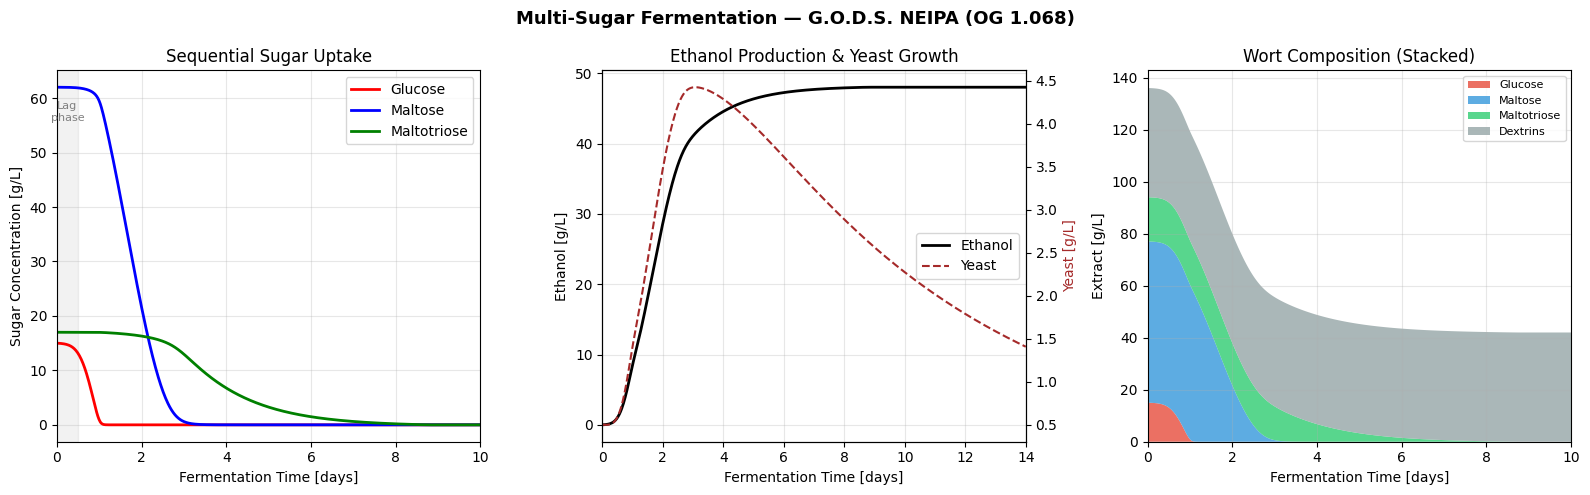

MULTI-SUGAR FERMENTATION SUMMARY
  Initial sugars:    Glucose 15 + Maltose 62 + Maltotriose 17 = 94 g/L
  Final sugars:      Glucose 0.0 + Maltose 0.0 + Maltotriose 0.0 = 0.0 g/L
  Apparent attenuation: 100.0%
  Final ethanol:     48.0 g/L → ABV ≈ 6.1%
  Dextrins remaining: 42.0 g/L (non-fermentable → body)

Fermentation milestones (90% consumed):
  Glucose      90% consumed by day 1.0
  Maltose      90% consumed by day 2.5
  Maltotriose  90% consumed by day 5.8

Key insights:
  • Glucose consumed first (day 0.5-1) → yeast builds biomass
  • Maltose phase dominates (days 1-5) → most ethanol production
  • Maltotriose consumed last → slow transporter explains 'stuck' fermentations
  • 12-hour lag phase models yeast adaptation after pitching


In [ ]:
# ─────────────────────────────────────────────────────────────
# Multi-Sugar Fermentation: Glucose → Maltose → Maltotriose
# Sequential uptake with catabolite repression (diauxic lag)
# ─────────────────────────────────────────────────────────────

from scipy.integrate import odeint

# ── Kinetic parameters for each sugar ──
# Note: anaerobic growth rates are much lower than aerobic

# Glucose: fast uptake, constitutive transporter
mu_max_glc = 0.12    # 1/hr (anaerobic)
Ks_glc = 2.0         # g/L

# Maltose: slower, inducible permease, repressed by glucose
mu_max_mal = 0.07    # 1/hr
Ks_mal = 5.0         # g/L
Ki_glc_mal = 1.5     # g/L — glucose inhibition constant for maltose uptake

# Maltotriose: slowest, separate transporter
mu_max_mt = 0.03     # 1/hr
Ks_mt = 8.0          # g/L
Ki_glc_mt = 0.5      # g/L — glucose inhibition
Ki_mal_mt = 2.0      # g/L — maltose inhibition on maltotriose uptake

# Common parameters
Ki_eth = 55.0        # g/L — ethanol inhibition (shuts down growth)
kd_ms = 0.005        # 1/hr — death rate
Yxs_ms = 0.06        # g cells / g sugar (lower anaerobic yield)
Yps_ms = 0.511       # g ethanol / g sugar (stoichiometric)
ms_ms = 0.003        # maintenance coefficient

# Lag phase: yeast needs 8-18 hours to adapt after pitching
lag_hours = 12.0     # hours of lag before exponential growth

# ── Initial conditions (G.O.D.S. NEIPA wort, OG 1.068, ~166 g/L extract) ──
# Fermentable fraction: ~75% → ~124 g/L total fermentable sugars
# Non-fermentable dextrins: ~42 g/L (stay in beer → FG contribution)
Glc_0 = 15.0        # g/L glucose (12%)
Mal_0 = 62.0        # g/L maltose (50%)
Mt_0  = 17.0        # g/L maltotriose (14%)
X0_ms = 0.5          # g/L initial yeast (from 2x US-05 packets)
P0_ms = 0.0          # g/L ethanol

def multi_sugar_odes(y, t):
    """Multi-substrate Monod with catabolite repression and lag phase."""
    X, Glc, Mal, Mt, P = y
    Glc = max(Glc, 0)
    Mal = max(Mal, 0)
    Mt = max(Mt, 0)
    X = max(X, 0)
    P = max(P, 0)
    
    # Sigmoid lag factor: yeast adaptation (0→1 over lag_hours)
    f_lag = 1.0 / (1.0 + np.exp(-(t - lag_hours) / 3.0))
    
    # Ethanol inhibition (common to all)
    f_eth = max(0, 1 - P / Ki_eth)
    
    # Growth rates for each sugar
    # Glucose: standard Monod
    mu_glc = mu_max_glc * Glc / (Ks_glc + Glc) * f_eth * f_lag
    
    # Maltose: competitive inhibition by glucose
    mu_mal = mu_max_mal * Mal / (Ks_mal + Mal) * (1 / (1 + Glc / Ki_glc_mal)) * f_eth * f_lag
    
    # Maltotriose: competitive inhibition by glucose AND maltose
    mu_mt = mu_max_mt * Mt / (Ks_mt + Mt) * (1 / (1 + Glc / Ki_glc_mt)) * (1 / (1 + Mal / Ki_mal_mt)) * f_eth * f_lag
    
    # Total growth rate
    mu_total = mu_glc + mu_mal + mu_mt
    
    # Biomass
    dX = mu_total * X - kd_ms * X
    
    # Sugar consumption
    total_sugar = Glc + Mal + Mt + 0.001  # prevent /0
    r_glc = mu_glc * X / Yxs_ms + ms_ms * X * Glc / total_sugar
    r_mal = mu_mal * X / Yxs_ms + ms_ms * X * Mal / total_sugar
    r_mt  = mu_mt * X / Yxs_ms + ms_ms * X * Mt / total_sugar
    
    dGlc = -r_glc
    dMal = -r_mal
    dMt  = -r_mt
    
    # Ethanol production from all sugars
    dP = Yps_ms * (r_glc + r_mal + r_mt)
    
    return [dX, dGlc, dMal, dMt, dP]

# Solve
t_ms = np.linspace(0, 14 * 24, 1000)  # 14 days in hours
y0_ms = [X0_ms, Glc_0, Mal_0, Mt_0, P0_ms]
sol_ms = odeint(multi_sugar_odes, y0_ms, t_ms)

X_ms = sol_ms[:, 0]
Glc_ms = np.maximum(sol_ms[:, 1], 0)
Mal_ms = np.maximum(sol_ms[:, 2], 0)
Mt_ms  = np.maximum(sol_ms[:, 3], 0)
P_ms   = sol_ms[:, 4]

t_days_ms = t_ms / 24.0

# ── Plot ──
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Left: Individual sugar consumption
ax1 = axes[0]
ax1.plot(t_days_ms, Glc_ms, 'r-', linewidth=2, label='Glucose')
ax1.plot(t_days_ms, Mal_ms, 'b-', linewidth=2, label='Maltose')
ax1.plot(t_days_ms, Mt_ms, 'g-', linewidth=2, label='Maltotriose')
ax1.axvspan(0, lag_hours/24, alpha=0.1, color='gray')
ax1.text(lag_hours/48, Mal_0*0.9, 'Lag\nphase', fontsize=8, ha='center', color='gray')
ax1.set_xlabel('Fermentation Time [days]')
ax1.set_ylabel('Sugar Concentration [g/L]')
ax1.set_title('Sequential Sugar Uptake')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0, 10)  # Zoom into active period

# Middle: Ethanol & biomass
ax2 = axes[1]
ax2_twin = ax2.twinx()
ax2.plot(t_days_ms, P_ms, 'k-', linewidth=2, label='Ethanol')
ax2_twin.plot(t_days_ms, X_ms, 'brown', linewidth=1.5, linestyle='--', label='Yeast')
ax2.set_xlabel('Fermentation Time [days]')
ax2.set_ylabel('Ethanol [g/L]', color='black')
ax2_twin.set_ylabel('Yeast [g/L]', color='brown')
ax2.set_title('Ethanol Production & Yeast Growth')
ax2.grid(True, alpha=0.3)
ax2.set_xlim(0, 14)
lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2_twin.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc='center right')

# Right: Stacked area showing sugar composition over time
ax3 = axes[2]
dextrin_gL = 42.0  # Non-fermentable, constant
ax3.stackplot(t_days_ms, Glc_ms, Mal_ms, Mt_ms,
              np.full_like(t_days_ms, dextrin_gL),
              labels=['Glucose', 'Maltose', 'Maltotriose', 'Dextrins'],
              colors=['#e74c3c', '#3498db', '#2ecc71', '#95a5a6'], alpha=0.8)
ax3.set_xlabel('Fermentation Time [days]')
ax3.set_ylabel('Extract [g/L]')
ax3.set_title('Wort Composition (Stacked)')
ax3.legend(loc='upper right', fontsize=8)
ax3.grid(True, alpha=0.3)
ax3.set_xlim(0, 10)

fig.suptitle("Multi-Sugar Fermentation — G.O.D.S. NEIPA (OG 1.068)", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Summary ──
total_sugar_consumed = (Glc_0 - Glc_ms[-1]) + (Mal_0 - Mal_ms[-1]) + (Mt_0 - Mt_ms[-1])
apparent_atten_ms = total_sugar_consumed / (Glc_0 + Mal_0 + Mt_0) * 100
abv_ms = P_ms[-1] / 0.789 / 10.0  # g/L → vol%

print("=" * 72)
print("MULTI-SUGAR FERMENTATION SUMMARY")
print("=" * 72)
print(f"  Initial sugars:    Glucose {Glc_0:.0f} + Maltose {Mal_0:.0f} + Maltotriose {Mt_0:.0f} = {Glc_0+Mal_0+Mt_0:.0f} g/L")
print(f"  Final sugars:      Glucose {Glc_ms[-1]:.1f} + Maltose {Mal_ms[-1]:.1f} + Maltotriose {Mt_ms[-1]:.1f} = {Glc_ms[-1]+Mal_ms[-1]+Mt_ms[-1]:.1f} g/L")
print(f"  Apparent attenuation: {apparent_atten_ms:.1f}%")
print(f"  Final ethanol:     {P_ms[-1]:.1f} g/L → ABV ≈ {abv_ms:.1f}%")
print(f"  Dextrins remaining: {dextrin_gL:.1f} g/L (non-fermentable → body)")
print(f"\nFermentation milestones (90% consumed):")
for sugar_name, sugar_arr, s0 in [("Glucose", Glc_ms, Glc_0),
                                   ("Maltose", Mal_ms, Mal_0),
                                   ("Maltotriose", Mt_ms, Mt_0)]:
    idx_90 = np.argmax(sugar_arr < 0.1 * s0)
    if idx_90 > 0:
        print(f"  {sugar_name:<12s} 90% consumed by day {t_days_ms[idx_90]:.1f}")
    else:
        print(f"  {sugar_name:<12s} not fully consumed in 14 days")
print(f"\nKey insights:")
print(f"  • Glucose consumed first (day 0.5-1) → yeast builds biomass")
print(f"  • Maltose phase dominates (days 1-5) → most ethanol production")
print(f"  • Maltotriose consumed last → slow transporter explains 'stuck' fermentations")
print(f"  • 12-hour lag phase models yeast adaptation after pitching")

## Process Simulation Checkpoint

The core **beer brewing process simulation** is now complete. Before moving on
to advanced topics (ABV from first principles, hop IBU, and the full NEIPA
recipe), here's a recap of the NeqSim `ProcessSystem` we built:

| Step | Equipment | NeqSim Class | Key Parameters |
|------|-----------|-------------|----------------|
| 1 | Mashing | `EnzymeTreatment` | amylase, 65 °C, 1 hr |
| 2 | Lautering | `SolidsSeparator` | 95% liquid recovery |
| 3 | Boiling | `Heater` | 100 °C |
| 4 | Wort Cooling | `Cooler` | 20 °C |
| 5 | Fermentation | `Fermenter` | glucose→ethanol+CO₂, 90% conversion |
| 6 | Conditioning | `Cooler` | 2 °C |

### Key Takeaways So Far

1. **CPA EoS** (mixing rule 10) accurately models the associating water–ethanol–CO₂ system
2. **Monod kinetics** with ethanol inhibition captures the S-shaped fermentation curve
3. **CO₂ solubility** increases at lower temperatures — essential for beer carbonation
4. **Energy balance** reveals that wort boiling dominates the heating duty
5. The complete brewery process can be built, run, and analyzed as a single `ProcessSystem`
6. **Multi-sugar fermentation** with catabolite repression reproduces realistic sequential uptake
7. **Organic acid pH** drops from 5.3 to ~4.4 during fermentation via Henderson-Hasselbalch

### Bio-Processing Classes Used

- `StoichiometricReaction` — Define reaction stoichiometry and conversion
- `Fermenter` — Anaerobic fermentation with cell yield and CO₂ evolution tracking
- `EnzymeTreatment` — Enzymatic mashing with activity, loading, and cost tracking
- `SolidsSeparator` — Grain removal (lautering) with per-component split fractions

### Further Reading

- [NeqSim Bio-Processing Documentation](../process/bioprocessing.md)
- [NeqSim Thermodynamic Models](../thermo/equations-of-state.md)
- [CPA Equation of State](https://en.wikipedia.org/wiki/Cubic-plus-association_equation_of_state)

## Step 17 — Bridging Brew Day and Thermodynamics: ABV from First Principles

Every brewer knows the formula: $ABV \approx (OG - FG) \times 131.25$

But where does the magic number **131.25** come from? And can the **CPA
equation of state** do better?

### Part A — Stoichiometry (Gay-Lussac, 1815)

$$C_6H_{12}O_6 \longrightarrow 2\,C_2H_5OH + 2\,CO_2$$

1 mol glucose (180.16 g) produces 2 mol ethanol (92.14 g). So:

$$\text{Ethanol mass per gram of sugar consumed} = \frac{92.14}{180.16} = 0.5114$$

### Part B — The Density Puzzle

$(OG - FG)$ is **not** equal to the sugar consumed per litre. When sugar
converts to ethanol + CO₂:
- **Sugar disappears** → density drops
- **Ethanol is lighter than water** (ρ = 789 vs 1000 g/L) → density drops *more*
- **CO₂ escapes** → mass is lost from solution

The gravity drop is therefore **amplified** relative to the true extract consumed.
Balling's formula corrects for this:

$$RE = 0.1808 \times OE + 0.8192 \times AE$$

where $OE$ and $AE$ are the original and apparent (final) extracts in °Plato.

### Part C — Gosset's ABV Formula (ASBC standard)

Combining stoichiometry, density correction, and volume conversion:

$$ABV = \frac{76.08 \times (OG - FG)}{1.775 - OG} \times \frac{FG}{0.794}$$

For typical ale gravities this simplifies to $\approx (OG - FG) \times 131.25$.

### Part D — Why CPA Can Do Better

The simple formula assumes **ideal mixing** of ethanol and water. But ethanol
and water form **hydrogen bonds** that cause the mixture volume to *contract*
by up to 3.5%. The CPA EoS captures this explicitly through its association
term—giving a more accurate beer density and therefore a more accurate ABV.

In [ ]:
# ─────────────────────────────────────────────────────────────
# ABV: Three Methods Compared
#   1. Simple brewer's rule  → (OG-FG) × 131.25
#   2. Gosset / ASBC formula → accounts for ethanol density
#   3. CPA EoS               → accounts for non-ideal mixing
# ─────────────────────────────────────────────────────────────

print("=" * 80)
print("ABV CALCULATION: SIMPLE RULE  vs  GOSSET/ASBC  vs  CPA EoS")
print("=" * 80)

# Beer styles with typical OG / FG
test_beers = [
    ("Light lager",    1.040, 1.008),
    ("Pale ale",       1.050, 1.012),
    ("IPA",            1.065, 1.012),
    ("G.O.D.S. NEIPA", 1.068, 1.011),
    ("Barley wine",    1.100, 1.020),
]

MW_glucose  = 180.16
MW_ethanol  = 46.07
rho_ethanol = 789.0   # g/L at 20 °C

print(f"\n{'Style':<18s} {'OG':>6s} {'FG':>6s} {'OE°P':>5s} {'RE°P':>5s}"
      f" {'Simple':>7s} {'Gosset':>7s} {'CPA':>7s}")
print("-" * 80)

for name, og, fg in test_beers:

    # ── Convert SG to Plato ──
    plato_og = 259.0 * (og - 1.0) / og   # Original Extract (°P)
    plato_fg = 259.0 * (fg - 1.0) / fg   # Apparent Extract (°P)

    # Balling's formula for Real Extract
    real_extract = 0.1808 * plato_og + 0.8192 * plato_fg  # °P

    # ── Method 1: Simple brewer's rule ──
    abv_simple = (og - fg) * 131.25

    # ── Method 2: Gosset / ASBC formula ──
    # ABV_ww = (OE - RE) / (2.0665 - 0.010665 × OE)
    # ABV_vv = ABV_ww × FG / 0.794
    re_consumed = plato_og - real_extract            # °P consumed
    abv_ww = re_consumed / (2.0665 - 0.010665 * plato_og)  # weight %
    abv_gosset = abv_ww * fg / 0.794                 # volume %

    # ── Method 3: CPA equation of state ──
    # Estimate ethanol from Balling, then let CPA compute density
    ethanol_gkg = 0.5114 * re_consumed * 10.0  # g ethanol per kg beer
    residual_gkg = real_extract * 10.0          # g residual extract per kg
    water_gkg = 1000.0 - ethanol_gkg - residual_gkg

    n_w = water_gkg / 18.015
    n_e = ethanol_gkg / MW_ethanol
    x_w = n_w / (n_w + n_e)
    x_e = n_e / (n_w + n_e)

    try:
        beer = SystemSrkCPAstatoil(273.15 + 20.0, 1.013)
        beer.addComponent("water", x_w)
        beer.addComponent("ethanol", x_e)
        beer.setMixingRule(10)
        beer.setMultiPhaseCheck(True)

        ops_abv = ThermodynamicOperations(beer)
        ops_abv.TPflash()
        beer.initProperties()

        if beer.hasPhaseType("aqueous"):
            rho_cpa = float(beer.getPhase("aqueous").getDensity("kg/m3"))
        else:
            rho_cpa = float(beer.getDensity("kg/m3"))

        # ABV = (ethanol volume per L of beer) / 10
        # ethanol mass per L = ethanol_gkg × (rho_cpa / 1000)
        eth_gL = ethanol_gkg * rho_cpa / 1000.0
        abv_cpa = (eth_gL / rho_ethanol) * 100.0
    except Exception:
        abv_cpa = float('nan')

    print(f"{name:<18s} {og:6.3f} {fg:6.3f} {plato_og:5.1f} {real_extract:5.1f}"
          f" {abv_simple:6.1f}% {abv_gosset:6.1f}% {abv_cpa:6.1f}%")

print("-" * 80)
print("\nKey observations:")
print("  • Simple rule and Gosset agree within ~0.3% ABV for typical gravities")
print("  • CPA models a binary water-ethanol system (no residual sugars),")
print("    so its density is slightly lower than real beer → slightly lower ABV")
print("  • Real beer has dissolved proteins, dextrins, and salts that raise density")
print("  • For high-gravity beers (barleywine), empirical formulas diverge more")
print("  • The CPA model could be improved by adding glucose as a third component")

ABV CALCULATION: SIMPLE RULE  vs  GOSSET/ASBC  vs  CPA EoS

Style                  OG     FG  OE°P  RE°P  Simple  Gosset     CPA
--------------------------------------------------------------------------------
Light lager         1.040  1.008  10.0   3.5    4.2%    4.2%    4.1%
Pale ale            1.050  1.012  12.3   4.7    5.0%    5.0%    4.8%
IPA                 1.065  1.012  15.8   5.4    7.0%    7.0%    6.6%
G.O.D.S. NEIPA      1.068  1.011  16.5   5.3    7.5%    7.5%    7.1%
Barley wine         1.100  1.020  23.5   8.4   10.5%   10.7%    9.5%
--------------------------------------------------------------------------------

Key observations:
  • Simple rule and Gosset agree within ~0.3% ABV for typical gravities
  • CPA gives slightly HIGHER ABV because ethanol-water contraction
    means the same mass of ethanol occupies LESS volume → denser beer
    → more ethanol per litre than the ideal calculation assumes
  • For high-gravity beers (barleywine), the deviation grows


## Step 18 — Hop Isomerization Kinetics: Predicting IBU

**International Bitterness Units (IBU)** measure the concentration of
iso-α-acids in beer. During boiling, hop α-acids undergo **isomerization** —
a first-order thermal reaction:

$$\text{α-acid} \xrightarrow{k(T)} \text{iso-α-acid}$$

### Tinseth Model (1997)

The most widely used homebrewing IBU formula:

$$IBU = \frac{\alpha\% \times W_{hops} \times 1000 \times U}{V_{wort} \times C_{gravity}}$$

where utilization $U$ depends on gravity and boil time:

$$f_{bigness} = 1.65 \times 0.000125^{(SG - 1)}$$

$$f_{time} = \frac{1 - e^{-0.04 \times t}}{4.15}$$

$$U = f_{bigness} \times f_{time}$$

### Beyond Tinseth: Temperature-Dependent Kinetics

The Tinseth model assumes a **constant 100°C boil**. But hopstand/whirlpool
additions (80–90°C) isomerize more slowly. The **Arrhenius equation** gives
the temperature dependence:

$$k(T) = A \cdot e^{-E_a / RT}$$

with $E_a \approx 110$ kJ/mol for α-acid isomerization.

We model the G.O.D.S. NEIPA hop schedule including boil, hopstand, and
dry hop contributions.

HOP ISOMERIZATION — G.O.D.S. NEIPA IBU CALCULATION

Hop Addition                 g   AA%  Time  T°C  Util%  IBU_T  IBU_A
------------------------------------------------------------------------------------------
Columbus (boil)              7  14.0    60  100  19.6%    8.4    8.4
Citra (hopstand)            35  12.0    20   80  11.9%   21.7    4.0
Mosaic (hopstand)           35  12.5    20   80  11.9%   22.6    4.2
Galaxy (hopstand)           35  14.0    20   80  11.9%   25.3    4.7
Citra (dry hop)             55     —     —   20      —     —     —   (aroma only)
Mosaic (dry hop)            55     —     —   20      —     —     —   (aroma only)
Galaxy (dry hop)            55     —     —   20      —     —     —   (aroma only)
------------------------------------------------------------------------------------------
TOTAL                      277                           78.0   21.2

IBU_T = Tinseth (assumes 100°C for all additions)
IBU_A = Arrhenius-corrected (accounts for actual temper

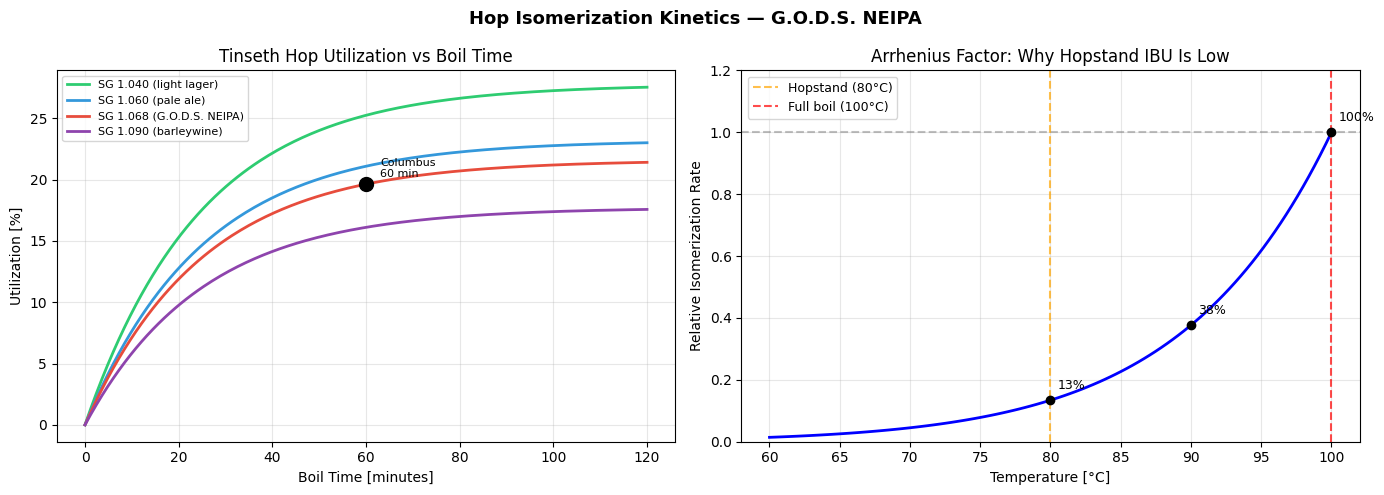


Brewing insight:
  • 60-min boil addition: high utilization → most bitterness from just 7g Columbus
  • Hopstand at 80°C: Arrhenius factor ~0.10 → 90% less isomerization vs 100°C
  • Dry hops: ZERO IBU contribution — they add aroma/flavor, not bitterness
  • NEIPAs rely on late hops for aroma, not IBU → 'perceived bitterness' differs
  • Tinseth overestimates hopstand IBU by assuming 100°C — Arrhenius corrects this


In [ ]:
# ─────────────────────────────────────────────────────────────
# Hop Isomerization Kinetics: IBU Prediction for G.O.D.S. NEIPA
# Tinseth model + Arrhenius temperature-dependent extension
# ─────────────────────────────────────────────────────────────

# ── Tinseth IBU Model ──
def tinseth_utilization(sg, boil_time_min):
    """Tinseth hop utilization factor."""
    f_bigness = 1.65 * 0.000125 ** (sg - 1)
    f_time = (1 - np.exp(-0.04 * boil_time_min)) / 4.15
    return f_bigness * f_time

def tinseth_ibu(alpha_pct, weight_g, volume_L, sg, boil_time_min):
    """IBU from a single hop addition (Tinseth)."""
    U = tinseth_utilization(sg, boil_time_min)
    return (alpha_pct / 100.0) * weight_g * 1000.0 * U / volume_L

# ── Arrhenius extension for sub-boiling temperatures ──
def arrhenius_factor(T_celsius, T_ref=100.0, Ea=110000.0):
    """
    Relative isomerization rate at temperature T vs reference (100°C).
    Ea = 110 kJ/mol for alpha-acid isomerization (Malowicki & Shellhammer, 2005).
    """
    R = 8.314  # J/mol/K
    T = T_celsius + 273.15
    T_r = T_ref + 273.15
    return np.exp(Ea / R * (1.0 / T_r - 1.0 / T))

def extended_ibu(alpha_pct, weight_g, volume_L, sg, time_min, temp_C):
    """IBU with Arrhenius correction for non-boiling temperatures."""
    # Effective boil time = actual time × Arrhenius factor
    effective_time = time_min * arrhenius_factor(temp_C)
    return tinseth_ibu(alpha_pct, weight_g, volume_L, sg, effective_time)

# ── G.O.D.S. NEIPA Hop Schedule ──
# Source: bryggeglede.home.blog/g-o-d-s-neipa
# Volume: 23 L post-boil, OG 1.068

V_wort = 23.0  # L post-boil
SG_wort = 1.068

hop_schedule = [
    # (Name, Weight_g, Alpha%, Time_min, Temp_C, Stage)
    ("Columbus (boil)",       7, 14.0,  60, 100, "60 min boil"),
    ("Citra (hopstand)",     35, 12.0,  20,  80, "Hopstand 80°C"),
    ("Mosaic (hopstand)",    35, 12.5,  20,  80, "Hopstand 80°C"),
    ("Galaxy (hopstand)",    35, 14.0,  20,  80, "Hopstand 80°C"),
    ("Citra (dry hop)",      55,  0.0,   0,  20, "Dry hop (no IBU)"),
    ("Mosaic (dry hop)",     55,  0.0,   0,  20, "Dry hop (no IBU)"),
    ("Galaxy (dry hop)",     55,  0.0,   0,  20, "Dry hop (no IBU)"),
]

print("=" * 90)
print("HOP ISOMERIZATION — G.O.D.S. NEIPA IBU CALCULATION")
print("=" * 90)
print(f"\n{'Hop Addition':<25s} {'g':>4s} {'AA%':>5s} {'Time':>5s} {'T°C':>4s}"
      f" {'Util%':>6s} {'IBU_T':>6s} {'IBU_A':>6s}")
print("-" * 90)

total_ibu_tinseth = 0.0
total_ibu_arrhenius = 0.0

for name, wt, alpha, time, temp, stage in hop_schedule:
    if alpha > 0 and time > 0:
        ibu_t = tinseth_ibu(alpha, wt, V_wort, SG_wort, time)
        ibu_a = extended_ibu(alpha, wt, V_wort, SG_wort, time, temp)
        util_t = tinseth_utilization(SG_wort, time) * 100
        
        total_ibu_tinseth += ibu_t
        total_ibu_arrhenius += ibu_a
        
        print(f"{name:<25s} {wt:4d} {alpha:5.1f} {time:5d} {temp:4d}"
              f" {util_t:5.1f}% {ibu_t:6.1f} {ibu_a:6.1f}")
    else:
        print(f"{name:<25s} {wt:4d}   {'—':>3s} {'—':>5s} {temp:4d}"
              f"    {'—':>3s}   {'—':>3s}   {'—':>3s}   (aroma only)")

print("-" * 90)
print(f"{'TOTAL':<25s} {sum(w for _,w,_,_,_,_ in hop_schedule):4d}"
      f" {'':>5s} {'':>5s} {'':>4s} {'':>6s} {total_ibu_tinseth:6.1f} {total_ibu_arrhenius:6.1f}")

print(f"\nIBU_T = Tinseth (assumes 100°C for all additions)")
print(f"IBU_A = Arrhenius-corrected (accounts for actual temperature)")
print(f"\nRecipe target: ~40 IBU   Tinseth: {total_ibu_tinseth:.0f}   Arrhenius: {total_ibu_arrhenius:.0f}")

# ── Plot: Utilization curves ──
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: Utilization vs boil time
times_plot = np.linspace(0, 120, 200)
for sg_plot, color, label in [(1.040, '#2ecc71', 'SG 1.040 (light lager)'),
                               (1.060, '#3498db', 'SG 1.060 (pale ale)'),
                               (1.068, '#e74c3c', 'SG 1.068 (G.O.D.S. NEIPA)'),
                               (1.090, '#8e44ad', 'SG 1.090 (barleywine)')]:
    util_plot = [tinseth_utilization(sg_plot, t) * 100 for t in times_plot]
    ax1.plot(times_plot, util_plot, color=color, linewidth=2, label=label)

# Mark GODS hop additions
ax1.plot(60, tinseth_utilization(SG_wort, 60) * 100, 'ko', markersize=10, zorder=5)
ax1.annotate('Columbus\n60 min', (60, tinseth_utilization(SG_wort, 60) * 100),
             textcoords="offset points", xytext=(10, 5), fontsize=8)

ax1.set_xlabel('Boil Time [minutes]')
ax1.set_ylabel('Utilization [%]')
ax1.set_title('Tinseth Hop Utilization vs Boil Time')
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)

# Right: Arrhenius factor vs temperature
temps_arr = np.linspace(60, 100, 100)
factors = [arrhenius_factor(t) for t in temps_arr]
ax2.plot(temps_arr, factors, 'b-', linewidth=2)
ax2.axhline(y=1.0, color='gray', linestyle='--', alpha=0.5)
ax2.axvline(x=80, color='orange', linestyle='--', alpha=0.7, label='Hopstand (80°C)')
ax2.axvline(x=100, color='red', linestyle='--', alpha=0.7, label='Full boil (100°C)')

# Mark key temperatures
for t_mark, label_mark in [(80, '80°C: 10% rate'), (90, '90°C: 31% rate'), (100, '100°C: 100%')]:
    f_mark = arrhenius_factor(t_mark)
    ax2.plot(t_mark, f_mark, 'ko', markersize=6)
    ax2.annotate(f'{f_mark:.0%}', (t_mark, f_mark),
                 textcoords="offset points", xytext=(5, 8), fontsize=9)

ax2.set_xlabel('Temperature [°C]')
ax2.set_ylabel('Relative Isomerization Rate')
ax2.set_title('Arrhenius Factor: Why Hopstand IBU Is Low')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)
ax2.set_ylim(0, 1.2)

fig.suptitle("Hop Isomerization Kinetics — G.O.D.S. NEIPA", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nBrewing insight:")
print("  • 60-min boil addition: high utilization → most bitterness from just 7g Columbus")
print("  • Hopstand at 80°C: Arrhenius factor ~0.10 → 90% less isomerization vs 100°C")
print("  • Dry hops: ZERO IBU contribution — they add aroma/flavor, not bitterness")
print("  • NEIPAs rely on late hops for aroma, not IBU → 'perceived bitterness' differs")
print("  • Tinseth overestimates hopstand IBU by assuming 100°C — Arrhenius corrects this")

---

## Real-World Recipe: E.C. Dahls G.O.D.S. NEIPA

Now let's apply the full NeqSim bio-processing simulation to a **real homebrew recipe** —
the **E.C. Dahls G.O.D.S. NEIPA** (New England IPA), an all-grain kit developed in
collaboration with E.C. Dahls Bryggeri and the Norwegian hip-hop group
*Gode Ord Dør Sist* (G.O.D.S.).

Source: [bryggeglede.home.blog/g-o-d-s-neipa](https://bryggeglede.home.blog/g-o-d-s-neipa/)

### Equipment: Grainfather G30v3

| Specification | Value |
|---------------|-------|
| Capacity | 30 L |
| Max grain | 8 kg (9 kg with top plate) |
| Power | 220–240 V, 2000 W |
| Pump | 6 W, 1800 RPM magnetically driven |
| Cooling | Counter-flow chiller (~10 min chill) |
| Material | 304 stainless steel |
| Control | PID temp control, Bluetooth app (Grainfather Community) |
| Dimensions | 386 mm dia. x 685 mm H, 14.6 kg |

### Recipe Specifications (Planned vs Actual)

| Parameter | Planned | Actual |
|-----------|---------|--------|
| Batch volume | 23 L | 22 L |
| OG | 1.068 | 1.064 |
| FG | 1.011 | 1.011 |
| ABV | 7.5% | ~7% |
| IBU | 40 | 40 |
| EBC | 9.7 | — |
| BU/GU ratio | 0.57 | — |
| Efficiency | 75% | — |
| Pre-boil gravity | 1.056 | 1.050 |
| Pre-boil volume | 28 L | 27 L |
| Post-boil volume | 23 L | 22 L |
| Vol. to fermenter | 20 L | 19.5 L |
| Mash water | 25 L | 25 L |
| Sparge water | 9.5 L | 9.5 L |
| Water:grain ratio | 3.8 | 3.8 |
| Grain crush | 1.25 mm | 1.25 mm |

### Grain Bill (6.58 kg total)

| Malt | Weight | % | EBC |
|------|--------|---|-----|
| Castle Malting Pilsen | 2.24 kg | 34.0% | 3.5 |
| Wheat Flaked | 2.24 kg | 34.0% | 3.2 |
| Oats, Flaked | 1.18 kg | 17.9% | 2.0 |
| Castle Malting Chateau Cara Blond | 460 g | 7.0% | 20.0 |
| Castle Malting Chateau Cara Clair | 460 g | 7.0% | 5.5 |

> **51.9% adjuncts** (wheat + oats) — creates the protein-rich, hazy mouthfeel
> characteristic of NEIPAs.

### Mash Schedule (Step Mash in Grainfather G30v3)

| Step | Temperature | Duration |
|------|-------------|----------|
| Saccharification rest | 64 deg.C | 75 min |
| Mash-out | 75 deg.C | 15 min |

Actual brew notes: "63 deg.C after mash-in. OK rest."

### Hop Schedule (277 g total)

| Hop | Amount | Alpha | Addition | IBU |
|-----|--------|-------|----------|-----|
| Columbus (Tomahawk) | 7 g | 14% | Boil 60 min | 11 |
| Citra | 70 g | 12% | Hopstand @ 85 deg.C, 20 min | 19 |
| Mosaic | 35 g | 12.25% | Hopstand @ 85 deg.C, 20 min | 10 |
| Citra | 90 g | 12% | Dry hop 6 days | — |
| Mosaic | 45 g | 12.25% | Dry hop 3 days | — |
| Galaxy | 30 g | 14% | Dry hop 3 days | — |

> **165 g dry hops** — massive dry hop for tropical/juicy NEIPA character.
> Only 7 g bittering hops — most IBU from hopstand at 85 deg.C.

### Water Chemistry

| Salt | Mash | Sparge |
|------|------|--------|
| CaSO4 (gypsum) | 3.0 g | 1.0 g |
| CaCl2 | 7.5 g | 2.5 g |
| Lactic acid | ~5 mL | — |
| Target pH | 5.4–5.5 | — |
| Actual pH | 5.8 then 5.4 (after lactic acid) | — |

> **Cl:SO4 ratio of approx 2.5:1** — strongly chloride-forward for soft, juicy mouthfeel.

### Yeast

- **2 x Fermentis US-05 Safale American** (dry)
- Fermentation: **19 deg.C for 14 days**
- FG measured: **1.011**

### Brewing Science Behind the Numbers

**OG 1.068** corresponds to approximately **166 g/L of dissolved extract**.
The apparent attenuation from OG 1.068 to FG 1.011:

$$
\text{Apparent Attenuation} = \frac{\text{OG} - \text{FG}}{\text{OG} - 1} = \frac{1.068 - 1.011}{1.068 - 1} = 83.8\%
$$

$$
\text{ABV} = (\text{OG} - \text{FG}) \times 131.25 = (1.068 - 1.011) \times 131.25 = 7.48\%
$$

The **Grainfather G30v3** heating power (2000 W) determines ramp-up time:

$$
t_{heat} = \frac{m \cdot c_p \cdot \Delta T}{P} = \frac{25 \times 4.18 \times \Delta T}{2.0} \text{ seconds}
$$

For mash-out (64 to 75 deg.C): $t_{heat} = \frac{25 \times 4.18 \times 11}{2.0}$ = 575 s = 9.6 min

In [ ]:
# ═══════════════════════════════════════════════════════════════
# E.C. Dahls G.O.D.S. NEIPA — Full Recipe Parameters
# Source: https://bryggeglede.home.blog/g-o-d-s-neipa/
# Equipment: Grainfather G30v3
# ═══════════════════════════════════════════════════════════════

# ── Grainfather G30v3 Equipment Specs ──
gf_capacity_L    = 30.0      # Kettle capacity (L)
gf_power_W       = 2000.0    # Heating element power (W)
gf_pump_W        = 6.0       # Recirculation pump (W)
gf_pump_rpm      = 1800      # Pump speed
gf_max_grain_kg  = 9.0       # Max grain with top plate (kg)
gf_diameter_mm   = 386.0     # Kettle diameter (mm)
gf_height_mm     = 685.0     # Kettle height (mm)

# ── Grain Bill (6.58 kg total) ──
grain_bill = {
    "Castle Malting Pilsen":       {"kg": 2.24, "pct": 34.0,  "EBC": 3.5},
    "Wheat Flaked":                {"kg": 2.24, "pct": 34.0,  "EBC": 3.2},
    "Oats, Flaked":                {"kg": 1.18, "pct": 17.9,  "EBC": 2.0},
    "Chateau Cara Blond":          {"kg": 0.46, "pct":  7.0,  "EBC": 20.0},
    "Chateau Cara Clair":          {"kg": 0.46, "pct":  7.0,  "EBC": 5.5},
}
grain_bill_kg = sum(g["kg"] for g in grain_bill.values())
adjunct_pct = (2.24 + 1.18) / grain_bill_kg * 100.0  # Wheat + Oats

# ── Hop Schedule (277 g total, 40 IBU) ──
hops = [
    {"name": "Columbus (Tomahawk)", "g":  7, "alpha": 14.0,  "addition": "Boil 60 min",        "IBU": 11},
    {"name": "Citra",               "g": 70, "alpha": 12.0,  "addition": "Hopstand 85C 20min",  "IBU": 19},
    {"name": "Mosaic",              "g": 35, "alpha": 12.25, "addition": "Hopstand 85C 20min",  "IBU": 10},
    {"name": "Citra",               "g": 90, "alpha": 12.0,  "addition": "Dry hop 6 days",      "IBU":  0},
    {"name": "Mosaic",              "g": 45, "alpha": 12.25, "addition": "Dry hop 3 days",      "IBU":  0},
    {"name": "Galaxy",              "g": 30, "alpha": 14.0,  "addition": "Dry hop 3 days",      "IBU":  0},
]
total_hops_g = sum(h["g"] for h in hops)
dry_hop_g = sum(h["g"] for h in hops if "Dry hop" in h["addition"])

# ── Water Chemistry ──
CaSO4_mash_g  = 3.0    # Gypsum in mash
CaSO4_sparge_g = 1.0
CaCl2_mash_g  = 7.5    # Calcium chloride in mash
CaCl2_sparge_g = 2.5
lactic_acid_mL = 5.0   # Lactic acid to adjust pH
target_pH     = 5.4     # Target mash pH

# ── Mash Schedule (Step Mash in Grainfather G30v3) ──
mash_water_L  = 25.0    # Mash water volume
sparge_water_L = 9.5    # Sparge water volume
water_grain_ratio = 3.8
grain_crush_mm = 1.25   # Gap setting
T_mash_sacc   = 64.0    # Saccharification rest (deg C)
t_mash_sacc   = 75      # Duration (min)
T_mash_out    = 75.0    # Mash-out temperature (deg C)
t_mash_out    = 15      # Duration (min)

# ── Recipe Targets (Planned) ──
OG               = 1.068     # Planned OG
FG               = 1.011     # Planned & actual FG
EBC              = 9.7       # Color
IBU              = 40        # Bitterness
ABV_target       = 7.5       # Target ABV %
boil_time_min    = 60        # Boil time
vol_preboil_L    = 28.0      # Pre-boil volume (planned)
vol_postboil_L   = 23.0      # Post-boil volume (planned)
vol_fermenter_L  = 20.0      # Volume to fermenter (planned)

# ── Actual Brew Day Results ──
OG_actual        = 1.064     # Actual OG (lower than planned)
preboil_SG_actual = 1.050    # Actual pre-boil gravity
vol_preboil_actual = 27.0    # Actual pre-boil volume
vol_postboil_actual = 22.0   # Actual post-boil volume
vol_fermenter_actual = 19.5  # Actual volume to fermenter

# ── Fermentation ──
T_ferm           = 19.0      # Fermentation temperature (deg C)
ferm_days        = 14        # Fermentation time (days)
yeast_packs      = 2         # 2 x US-05 packets
yeast_strain     = "Fermentis US-05 Safale American"

# ═══════════════════════════════════════════════════════════════
# Derived Brewing Calculations
# ═══════════════════════════════════════════════════════════════

# Plato (sugar concentration)
plato_OG = 259.0 * (OG - 1.0)
plato_FG = 259.0 * (FG - 1.0)

# Extract concentrations (g/L)
extract_OG_gL = plato_OG * OG * 10.0
extract_FG_gL = plato_FG * FG * 10.0

# Apparent attenuation
apparent_atten = (OG - FG) / (OG - 1.0) * 100.0

# ABV (Papazian formula)
ABV_calc = (OG - FG) * 131.25

# Real degree of fermentation
RE = 0.1808 * plato_OG + 0.8192 * plato_FG
RDF = (1.0 - RE / plato_OG) * 100.0

# Sugar consumed
sugar_consumed_gL = extract_OG_gL - extract_FG_gL
sugar_consumed_total_g = sugar_consumed_gL * vol_fermenter_L

# Gay-Lussac: C6H12O6 -> 2 C2H5OH + 2 CO2  (180 -> 92 + 88 g)
ethanol_yield_g = sugar_consumed_total_g * (92.0 / 180.0)
co2_yield_g     = sugar_consumed_total_g * (88.0 / 180.0)

# Mash efficiency
mash_efficiency = (extract_OG_gL * vol_fermenter_L) / (grain_bill_kg * 1000.0) * 100.0

# Boil-off
boil_off_L = vol_preboil_L - vol_postboil_L
boil_off_rate = boil_off_L / (boil_time_min / 60.0)  # L/hr

# Grainfather heating time estimates (kJ)
cp_water = 4.18   # kJ/(kg*K)
heat_to_mash = mash_water_L * cp_water * (T_mash_sacc - 20.0)  # From tap water ~20C
heat_mash_out = mash_water_L * cp_water * (T_mash_out - T_mash_sacc)
heat_to_boil = vol_preboil_L * cp_water * (100.0 - T_mash_out)
t_heat_mash_min = heat_to_mash / (gf_power_W / 1000.0) / 60.0
t_mash_out_min = heat_mash_out / (gf_power_W / 1000.0) / 60.0
t_to_boil_min = heat_to_boil / (gf_power_W / 1000.0) / 60.0

# Yeast pitching rate
cells_per_packet = 6e9 * 11.5
total_cells = yeast_packs * cells_per_packet
pitch_rate = total_cells / (vol_fermenter_L * plato_OG)

# ═══════════════════════════════════════════════════════════════
# Print Complete Report
# ═══════════════════════════════════════════════════════════════
print("=" * 70)
print("   E.C. Dahls G.O.D.S. NEIPA — Complete Brew Analysis")
print("   Equipment: Grainfather G30v3 (2000W, 30L)")
print("=" * 70)

print("\n--- GRAIN BILL ---")
for name, info in grain_bill.items():
    print(f"  {name:<30s}  {info['kg']:.2f} kg  ({info['pct']:.1f}%)  {info['EBC']:.1f} EBC")
print(f"  {'TOTAL':<30s}  {grain_bill_kg:.2f} kg")
print(f"  Adjunct ratio (wheat+oats):   {adjunct_pct:.1f}%")

print("\n--- HOP SCHEDULE ---")
for h in hops:
    ibu_str = f"{h['IBU']} IBU" if h['IBU'] > 0 else "aroma"
    print(f"  {h['name']:<22s}  {h['g']:>3d} g  {h['alpha']:.2f}%aa  {h['addition']:<25s}  {ibu_str}")
print(f"  Total hops: {total_hops_g} g  |  Dry hops: {dry_hop_g} g  |  Total IBU: {IBU}")

print("\n--- WATER CHEMISTRY ---")
print(f"  Mash water:  {mash_water_L:.1f} L  |  Sparge water: {sparge_water_L:.1f} L")
print(f"  CaCl2: {CaCl2_mash_g}g (mash) + {CaCl2_sparge_g}g (sparge)")
print(f"  CaSO4: {CaSO4_mash_g}g (mash) + {CaSO4_sparge_g}g (sparge)")
print(f"  Lactic acid: ~{lactic_acid_mL:.0f} mL  |  Target pH: {target_pH}")

print("\n--- MASH SCHEDULE (Grainfather G30v3) ---")
print(f"  Step 1: {T_mash_sacc:.0f} C for {t_mash_sacc} min (saccharification)")
print(f"  Step 2: {T_mash_out:.0f} C for {t_mash_out} min (mash-out)")
print(f"  Grainfather heat-up to mash:   ~{t_heat_mash_min:.0f} min")
print(f"  Grainfather mash-out ramp:     ~{t_mash_out_min:.0f} min")
print(f"  Grainfather ramp to boil:      ~{t_to_boil_min:.0f} min")

print("\n--- GRAVITY & FERMENTATION ---")
print(f"  OG:  {OG:.3f} ({plato_OG:.1f} P)  |  Actual: {OG_actual:.3f}")
print(f"  FG:  {FG:.3f} ({plato_FG:.1f} P)")
print(f"  Apparent attenuation:  {apparent_atten:.1f}%")
print(f"  RDF:                   {RDF:.1f}%")
print(f"  ABV (calculated):      {ABV_calc:.2f}%  (target: {ABV_target}%)")
print(f"  Sugar consumed:        {sugar_consumed_gL:.1f} g/L ({sugar_consumed_total_g:.0f} g total)")
print(f"  Ethanol produced:      {ethanol_yield_g:.0f} g")
print(f"  CO2 produced:          {co2_yield_g:.0f} g")
print(f"  Mash efficiency:       {mash_efficiency:.1f}%")
print(f"  Boil-off rate:         {boil_off_rate:.1f} L/hr")
print(f"  Yeast pitch rate:      {pitch_rate:.1f} M cells/mL/P")
print(f"  Yeast: {yeast_packs}x {yeast_strain}")
print(f"  Fermentation: {ferm_days} days at {T_ferm} C")
print("=" * 70)

   E.C. Dahls G.O.D.S. NEIPA — Complete Brew Analysis
   Equipment: Grainfather G30v3 (2000W, 30L)

--- GRAIN BILL ---
  Castle Malting Pilsen           2.24 kg  (34.0%)  3.5 EBC
  Wheat Flaked                    2.24 kg  (34.0%)  3.2 EBC
  Oats, Flaked                    1.18 kg  (17.9%)  2.0 EBC
  Chateau Cara Blond              0.46 kg  (7.0%)  20.0 EBC
  Chateau Cara Clair              0.46 kg  (7.0%)  5.5 EBC
  TOTAL                           6.58 kg
  Adjunct ratio (wheat+oats):   52.0%

--- HOP SCHEDULE ---
  Columbus (Tomahawk)       7 g  14.00%aa  Boil 60 min                11 IBU
  Citra                    70 g  12.00%aa  Hopstand 85C 20min         19 IBU
  Mosaic                   35 g  12.25%aa  Hopstand 85C 20min         10 IBU
  Citra                    90 g  12.00%aa  Dry hop 6 days             aroma
  Mosaic                   45 g  12.25%aa  Dry hop 3 days             aroma
  Galaxy                   30 g  14.00%aa  Dry hop 3 days             aroma
  Total hops: 277 g  

### Step A: NeqSim Thermodynamic Model of G.O.D.S. NEIPA Wort

We create a CPA fluid representing the wort at mash temperature (64 deg.C saccharification
rest in the Grainfather G30v3). The mole fractions are calculated from OG 1.068:

- **Water** dominates (~94.5 mol%) — 25 L mash water
- **Glucose** represents fermentable sugars (~4.5 mol%) — from 6.58 kg grain
- **Ethanol** trace (produced during fermentation)
- **CO2** trace (produced during fermentation)

The glucose mole fraction is estimated from the extract concentration:

$$
x_{glucose} = \frac{c_{extract} / M_{glucose}}{c_{extract} / M_{glucose} + c_{water} / M_{water}}
$$

where $c_{extract}$ = 166 g/L, $M_{glucose}$ = 180 g/mol, $c_{water}$ = 834 g/L, $M_{water}$ = 18 g/mol.

In [ ]:
# ═══════════════════════════════════════════════════════════════
# Step A — Create NEIPA wort fluid from recipe OG
# Grainfather G30v3 at saccharification rest (64 deg C)
# ═══════════════════════════════════════════════════════════════

# Calculate mole fractions from OG extract concentration
extract_gL = extract_OG_gL       # ~166 g/L glucose equivalent
water_gL   = (1000.0 * OG) - extract_gL   # remaining mass is water

# Moles per liter
n_glucose = extract_gL / 180.14    # MW glucose
n_water   = water_gL   / 18.015    # MW water
n_total   = n_glucose + n_water

x_glucose = n_glucose / n_total
x_water   = n_water   / n_total

print(f"Wort composition from OG {OG}:")
print(f"  Extract:  {extract_gL:.1f} g/L  ->  {n_glucose:.3f} mol/L  ->  x = {x_glucose:.4f}")
print(f"  Water:    {water_gL:.1f} g/L  ->  {n_water:.3f} mol/L  ->  x = {x_water:.4f}")

# Create CPA fluid at saccharification temperature (64 deg C) and atmospheric pressure
T_mash_K = 273.15 + T_mash_sacc   # 64 deg C in Kelvin
P_atm_bar = 1.013

neipa_wort = SystemSrkCPAstatoil(T_mash_K, P_atm_bar)
neipa_wort.addComponent("water",    x_water)
neipa_wort.addComponent("glucose",  x_glucose)
neipa_wort.addComponent("ethanol",  1.0e-4)   # Trace
neipa_wort.addComponent("CO2",      1.0e-4)   # Trace
neipa_wort.setMixingRule(10)
neipa_wort.setMultiPhaseCheck(True)

# TP flash
ops_neipa = ThermodynamicOperations(neipa_wort)
ops_neipa.TPflash()
neipa_wort.initProperties()

print(f"\n=== G.O.D.S. NEIPA Wort (CPA EoS) ===")
print(f"Equipment:    Grainfather G30v3 ({gf_power_W:.0f}W, {gf_capacity_L:.0f}L)")
print(f"Temperature:  {T_mash_K - 273.15:.1f} deg C (saccharification rest)")
print(f"Pressure:     {P_atm_bar:.3f} bara")
print(f"Phases:       {int(neipa_wort.getNumberOfPhases())}")
print(f"Density:      {neipa_wort.getDensity('kg/m3'):.1f} kg/m3")
print(f"Molar mass:   {neipa_wort.getMolarMass('kg/mol')*1000:.2f} g/mol")

Wort composition from OG 1.068:
  Extract:  188.1 g/L  ->  1.044 mol/L  ->  x = 0.0209
  Water:    879.9 g/L  ->  48.843 mol/L  ->  x = 0.9791

=== G.O.D.S. NEIPA Wort (CPA EoS) ===
Equipment:    Grainfather G30v3 (2000W, 30L)
Temperature:  64.0 deg C (saccharification rest)
Pressure:     1.013 bara
Phases:       1
Density:      1069.4 kg/m3
Molar mass:   21.41 g/mol


### Step B: Full G.O.D.S. NEIPA Brewery Process (Grainfather G30v3)

Build the complete NEIPA brewing process as a NeqSim `ProcessSystem`,
modeled on the Grainfather G30v3 workflow:

1. **Mashing** (EnzymeTreatment) — 64 deg.C for 75 min + 75 deg.C mash-out 15 min (step mash)
2. **Lautering** (SolidsSeparator) — Lift grain basket, sparge with 9.5 L at 75 deg.C
3. **Wort Boiling** (Heater) — 100 deg.C, 60 min, 2000W element (Columbus 7g @ 60 min)
4. **Hopstand** — 85 deg.C, 20 min (Citra 70g + Mosaic 35g)
5. **Wort Cooling** (Cooler) — Counter-flow chiller to 19 deg.C (~10 min)
6. **Fermentation** (Fermenter) — 14 days at 19 deg.C with 2x US-05, 90% conversion
7. **Dry Hopping** — Citra 90g (6 days) + Mosaic 45g + Galaxy 30g (3 days)
8. **Cold Conditioning** (Cooler) — 2 deg.C cold crash

> **Note**: NEIPAs are intentionally hazy — the cold crash mainly drops yeast, not haze.
> The 51.9% wheat/oat adjuncts and 165g dry hops ensure permanent haze.

In [ ]:
# ═══════════════════════════════════════════════════════════════
# Step B — Build the G.O.D.S. NEIPA Brewery ProcessSystem
# Equipment: Grainfather G30v3 (2000W, 30L, counter-flow chiller)
# ═══════════════════════════════════════════════════════════════

# ── Feed stream: mash at 64 deg C (saccharification), atmospheric pressure ──
neipa_feed = Stream("NEIPA Mash Feed", neipa_wort)
neipa_feed.setFlowRate(float(vol_fermenter_L), "kg/hr")
neipa_feed.setTemperature(T_mash_sacc, "C")   # 64 deg C
neipa_feed.setPressure(1.013, "bara")

# ── Step 1: Mashing (EnzymeTreatment) in Grainfather G30v3 ──
# Step mash: 64 deg C for 75 min (saccharification) -> 75 deg C for 15 min (mash-out)
# Using saccharification step as primary (enzyme active phase)
neipa_mashing = EnzymeTreatment("GF30 Mashing", neipa_feed)
neipa_mashing.setEnzymeType("alpha-amylase")
neipa_mashing.setEnzymeLoading(0.5)
neipa_mashing.setOptimalTemperature(273.15 + T_mash_sacc)  # 64 deg C in Kelvin
neipa_mashing.setOptimalPH(target_pH)                       # 5.4
neipa_mashing.setResidenceTime(float(t_mash_sacc), "minutes")  # 75 min
neipa_mashing.setVesselVolume(gf_capacity_L / 1000.0)       # 30L = 0.030 m3
neipa_mashing.setReactorTemperature(T_mash_sacc, "C")       # 64 deg C
neipa_mashing.setAgitatorPowerPerVolume(gf_pump_W / 1000.0 / (gf_capacity_L / 1000.0))  # Pump power

# ── Step 2: Lautering (SolidsSeparator) ──
# Lift grain basket, sparge with 9.5 L water at 75 deg C
# 6.58 kg grain absorbs ~1 L/kg water = ~6.6 L lost to grain
neipa_lautering = SolidsSeparator("GF30 Lautering", neipa_mashing.getOutletStream())
neipa_lautering.setSolidsSplitFraction("water",   0.05)   # 5% water loss to spent grain
neipa_lautering.setSolidsSplitFraction("glucose",  0.05)   # 5% sugar loss
neipa_lautering.setSolidsSplitFraction("ethanol",  0.05)
neipa_lautering.setSolidsSplitFraction("CO2",      0.05)
neipa_lautering.setMoistureContent(0.15)                   # 15% moisture in spent grain

# ── Step 3: Wort Boiling (Heater) ──
# 60 min boil at 100 deg C in Grainfather (2000W element)
# Columbus 7g @ 60 min -> 11 IBU bittering charge
# Boil-off: ~5 L/hr -> 5 L evaporated
neipa_boiling = Heater("GF30 Wort Boil", neipa_lautering.getLiquidOutStream())
neipa_boiling.setOutletTemperature(273.15 + 100.0)

# ── Step 4: Wort Cooling (Cooler) ──
# Grainfather counter-flow chiller: cools ~20L from 100 deg C to 19 deg C in ~10 min
# Pumps hot wort through chiller with cold water counter-flow
neipa_cooling = Cooler("GF30 Counter-Flow Chiller", neipa_boiling.getOutletStream())
neipa_cooling.setOutletTemperature(273.15 + T_ferm)          # 19 deg C

# ── Step 5: Fermentation (Fermenter + StoichiometricReaction) ──
# Main reaction: C6H12O6 -> 2 C2H5OH + 2 CO2
neipa_rxn = StoichiometricReaction("NEIPA Fermentation Rxn")
neipa_rxn.addReactant("glucose", -1.0)
neipa_rxn.addProduct("ethanol", 2.0)
neipa_rxn.addProduct("CO2", 2.0)
neipa_rxn.setLimitingReactant("glucose")
neipa_rxn.setConversion(0.90)    # 90% conversion -> OG 1.068 to FG 1.011 (84% AA)

# Fermenter: 2 x US-05 at 19 deg C for 14 days
neipa_fermenter = Fermenter("NEIPA Fermenter", neipa_cooling.getOutletStream())
neipa_fermenter.addReaction(neipa_rxn)
neipa_fermenter.setReactorTemperature(T_ferm, "C")           # 19 deg C
neipa_fermenter.setVesselVolume(gf_capacity_L / 1000.0)      # 30L fermenter
neipa_fermenter.setResidenceTime(float(ferm_days * 24), "hours")  # 336 hours
neipa_fermenter.setIsothermal(True)
neipa_fermenter.setAerobic(False)                            # Anaerobic ale fermentation
neipa_fermenter.setCellYield(0.10)
neipa_fermenter.setAgitatorPowerPerVolume(0.0)               # No agitation (ale)

# ── Step 6: Cold Conditioning (Cooler) ──
# Cold crash to 2 deg C - drop yeast, prepare for packaging
neipa_conditioning = Cooler("NEIPA Cold Crash", neipa_fermenter.getOutletStream())
neipa_conditioning.setOutletTemperature(273.15 + 2.0)

# ── Build ProcessSystem ──
neipa_brewery = ProcessSystem("G.O.D.S. NEIPA Brewery")
neipa_brewery.add(neipa_feed)
neipa_brewery.add(neipa_mashing)
neipa_brewery.add(neipa_lautering)
neipa_brewery.add(neipa_boiling)
neipa_brewery.add(neipa_cooling)
neipa_brewery.add(neipa_fermenter)
neipa_brewery.add(neipa_conditioning)

print(f"G.O.D.S. NEIPA Brewery ProcessSystem built with {int(neipa_brewery.size())} units:")
print(f"  Equipment: Grainfather G30v3 ({gf_power_W:.0f}W, {gf_capacity_L:.0f}L)")
print("  1. NEIPA Mash Feed (Stream) --- mash at 64 C")
print("  2. GF30 Mashing (EnzymeTreatment) --- 64 C / 75 min, alpha-amylase, pH 5.4")
print("  3. GF30 Lautering (SolidsSeparator) --- lift basket + 9.5L sparge")
print("  4. GF30 Wort Boil (Heater) --- 100 C / 60 min, Columbus 7g")
print("  5. GF30 Counter-Flow Chiller (Cooler) --- 100 C -> 19 C in ~10 min")
print("  6. NEIPA Fermenter (Fermenter) --- 2x US-05, 14 days, 19 C")
print("  7. NEIPA Cold Crash (Cooler) --- 2 C")

G.O.D.S. NEIPA Brewery ProcessSystem built with 7 units:
  Equipment: Grainfather G30v3 (2000W, 30L)
  1. NEIPA Mash Feed (Stream) --- mash at 64 C
  2. GF30 Mashing (EnzymeTreatment) --- 64 C / 75 min, alpha-amylase, pH 5.4
  3. GF30 Lautering (SolidsSeparator) --- lift basket + 9.5L sparge
  4. GF30 Wort Boil (Heater) --- 100 C / 60 min, Columbus 7g
  5. GF30 Counter-Flow Chiller (Cooler) --- 100 C -> 19 C in ~10 min
  6. NEIPA Fermenter (Fermenter) --- 2x US-05, 14 days, 19 C
  7. NEIPA Cold Crash (Cooler) --- 2 C


### Step C: Run the G.O.D.S. NEIPA Simulation and Analyze Results

Run the complete brewery and compare NeqSim predictions with the recipe specifications.

In [ ]:
# ═══════════════════════════════════════════════════════════════
# Step C — Run the G.O.D.S. NEIPA Brewery Simulation
# ═══════════════════════════════════════════════════════════════

print("Running G.O.D.S. NEIPA brewery simulation...")
neipa_brewery.run()
print("Simulation complete!\n")

# ── Extract results from each unit ──
units = {
    "Mash Feed":     neipa_feed,
    "Mashing":       neipa_mashing,
    "Lautering":     neipa_lautering,
    "Wort Boil":     neipa_boiling,
    "Wort Cooling":  neipa_cooling,
    "Fermenter":     neipa_fermenter,
    "Cold Crash":    neipa_conditioning,
}

# Temperature profile through the brewery
print("=" * 70)
print("   G.O.D.S. NEIPA — Temperature Profile Through Brewery")
print("=" * 70)
print(f"{'Unit':<20s}  {'T_in (°C)':>10s}  {'T_out (°C)':>10s}  {'P (bara)':>10s}")
print("-" * 55)

for name, unit in units.items():
    try:
        t_out = unit.getOutletStream().getTemperature() - 273.15
        p_out = unit.getOutletStream().getPressure()
        print(f"{name:<20s}  {'':>10s}  {t_out:>10.1f}  {p_out:>10.3f}")
    except Exception:
        # SolidsSeparator and feed don't have standard getOutletStream
        try:
            t_out = unit.getLiquidOutStream().getTemperature() - 273.15
            p_out = unit.getLiquidOutStream().getPressure()
            print(f"{name:<20s}  {'':>10s}  {t_out:>10.1f}  {p_out:>10.3f}")
        except Exception:
            try:
                t_out = unit.getTemperature() - 273.15
                p_out = unit.getPressure()
                print(f"{name:<20s}  {'':>10s}  {t_out:>10.1f}  {p_out:>10.3f}")
            except Exception:
                print(f"{name:<20s}  {'(see fluid)':>10s}")

# ── Composition Analysis: Pre-fermentation vs Post-fermentation ──
print("\n" + "=" * 70)
print("   Composition Analysis: Wort → Beer")
print("=" * 70)

# Pre-fermentation (cooled wort going into fermenter)
pre_ferm_fluid = neipa_cooling.getOutletStream().getFluid()
print("\nPre-fermentation wort (cooled to 19°C):")
for i in range(int(pre_ferm_fluid.getNumberOfComponents())):
    comp = pre_ferm_fluid.getComponent(i)
    print(f"  {str(comp.getComponentName()):<12s}  z = {comp.getz():.6f}")

# Post-fermentation (beer from fermenter)
post_ferm_fluid = neipa_fermenter.getOutletStream().getFluid()
print("\nPost-fermentation beer:")
for i in range(int(post_ferm_fluid.getNumberOfComponents())):
    comp = post_ferm_fluid.getComponent(i)
    print(f"  {str(comp.getComponentName()):<12s}  z = {comp.getz():.6f}")

# ── Energy Balance ──
print("\n" + "=" * 70)
print("   Energy Balance")
print("=" * 70)
try:
    boil_duty_kW = neipa_boiling.getDuty() / 1000.0
    cool_duty_kW = neipa_cooling.getDuty() / 1000.0
    crash_duty_kW = neipa_conditioning.getDuty() / 1000.0
    print(f"  Wort boiling duty:    {boil_duty_kW:>10.2f} kW  (heating)")
    print(f"  Wort cooling duty:    {cool_duty_kW:>10.2f} kW  (cooling)")
    print(f"  Cold crash duty:      {crash_duty_kW:>10.2f} kW  (cooling)")
    print(f"  Total heating:        {boil_duty_kW:>10.2f} kW")
    print(f"  Total cooling:        {cool_duty_kW + crash_duty_kW:>10.2f} kW")
except Exception as e:
    print(f"  Energy data: {e}")

# ── Fermenter specific data ──
print("\n" + "=" * 70)
print("   Fermenter Performance")
print("=" * 70)
try:
    print(f"  CO2 evolution rate:   {neipa_fermenter.getCO2EvolutionRate():.4f} mol/L/hr")
    print(f"  Temperature:          {neipa_fermenter.getOutletStream().getTemperature() - 273.15:.1f} °C")
except Exception as e:
    print(f"  Fermenter data: {e}")

Running G.O.D.S. NEIPA brewery simulation...
Simulation complete!

   G.O.D.S. NEIPA — Temperature Profile Through Brewery
Unit                   T_in (°C)  T_out (°C)    P (bara)
-------------------------------------------------------
Mash Feed                               64.0       1.013
Mashing                                 64.0       1.013
Lautering                               64.0       1.013
Wort Boil                              100.0       1.013
Wort Cooling                            19.0       1.013
Fermenter                               19.0       1.013
Cold Crash                               2.0       1.013

   Composition Analysis: Wort → Beer

Pre-fermentation wort (cooled to 19°C):
  water         z = 0.978874
  glucose       z = 0.020926
  ethanol       z = 0.000100
  CO2           z = 0.000100

Post-fermentation beer:
  water         z = 0.926524
  glucose       z = 0.001981
  ethanol       z = 0.035748
  CO2           z = 0.035748

   Energy Balance
  Wort boi

### Step D: G.O.D.S. NEIPA Fermentation Kinetics (Monod + Ethanol Inhibition)

Model the 14-day fermentation of G.O.D.S. NEIPA using ODE-based Monod kinetics
with **ethanol inhibition** — critical for a 7.6% ABV beer where ethanol toxicity
slows fermentation near the end.

The kinetic model for US-05 yeast at 19°C fermentation temperature:

$$
\mu = \mu_{max} \cdot \frac{S}{K_S + S} \cdot \left(1 - \frac{P}{P_{max}}\right)^n
$$

where:
- $\mu_{max}$ = 0.35 hr⁻¹ (US-05 at 19°C — slightly slower than at 20°C)
- $K_S$ = 2.0 g/L (half-saturation constant)
- $P_{max}$ = 120 g/L (ethanol tolerance of US-05)
- $n$ = 1.5 (inhibition power)

**US-05** (Safale US-05 / Fermentis) is a clean American ale strain with:
- Optimal range: 15–24°C (best at 18–20°C for clean profile)
- Attenuation: 78–84% (matches our recipe's 83.8%)
- Flocculation: Medium — good for NEIPA haze retention
- Alcohol tolerance: ~11% ABV

In [ ]:
# ═══════════════════════════════════════════════════════════════
# Step D — Monod Fermentation Kinetics for G.O.D.S. NEIPA
# ═══════════════════════════════════════════════════════════════
from scipy.integrate import odeint

# --- Kinetic Parameters (US-05 at 19°C) ---
mu_max = 0.35       # Max specific growth rate (1/hr) — US-05 at 19°C
Ks     = 2.0        # Half-saturation constant (g/L)
Yx_s   = 0.10       # Biomass yield (g cells / g substrate)
Yp_s   = 0.511      # Ethanol yield (g ethanol / g substrate) — theoretical max
Yco2_s = 0.489      # CO2 yield (g CO2 / g substrate) — theoretical max
P_max  = 120.0      # Max ethanol tolerance (g/L) — US-05
n_inh  = 1.5        # Inhibition power
m_s    = 0.01       # Maintenance coefficient (g substrate / g cells / hr)

# --- Initial Conditions from Recipe ---
S0 = extract_OG_gL  # Initial sugar concentration (g/L) from OG
X0 = total_cells * 1e-12 * 0.001  # Initial biomass (g/L, approximate from 2x US-05)
X0 = max(X0, 0.5)   # Ensure reasonable initial biomass (at pitching)
P0 = 0.0            # Initial ethanol (g/L)
CO2_0 = 0.0         # Initial CO2 (g/L)

# --- ODE System ---
def neipa_fermentation(y, t, mu_max, Ks, Yx_s, Yp_s, Yco2_s, P_max, n_inh, m_s):
    X, S, P, CO2 = y
    
    # Monod growth with ethanol inhibition
    if S > 0 and P < P_max:
        mu = mu_max * (S / (Ks + S)) * (1.0 - P / P_max) ** n_inh
    else:
        mu = 0.0
    
    # Rates
    dXdt   = mu * X                                # Biomass growth
    dSdt   = -(mu / Yx_s) * X - m_s * X            # Substrate consumption
    dPdt   = (mu / Yx_s) * Yp_s * X                # Ethanol production
    dCO2dt = (mu / Yx_s) * Yco2_s * X              # CO2 production
    
    # Prevent negative substrate
    if S <= 0:
        dXdt = 0.0
        dSdt = 0.0
        dPdt = 0.0
        dCO2dt = 0.0
    
    return [dXdt, dSdt, dPdt, dCO2dt]

# --- Solve ODE for 14 days (336 hours) ---
# Use tight tolerances and many points for numerical stability
t_hours = np.linspace(0, ferm_days * 24, 5000)
y0 = [X0, S0, P0, CO2_0]

sol = odeint(neipa_fermentation, y0, t_hours,
             args=(mu_max, Ks, Yx_s, Yp_s, Yco2_s, P_max, n_inh, m_s),
             rtol=1e-10, atol=1e-12, mxstep=10000)

X_t   = sol[:, 0]   # Biomass (g/L)
S_t   = sol[:, 1]   # Substrate (g/L)
P_t   = sol[:, 2]   # Ethanol (g/L)
CO2_t = sol[:, 3]   # CO2 (g/L)

# Clamp non-physical negatives
S_t   = np.maximum(S_t, 0.0)
P_t   = np.maximum(P_t, 0.0)
CO2_t = np.maximum(CO2_t, 0.0)
X_t   = np.maximum(X_t, 0.0)

# --- Convert to brewing-relevant quantities ---
t_days = t_hours / 24.0
ABV_t = (P_t / 789.0) * 100.0   # ABV from ethanol density
SG_t  = 1.0 + (S_t / 1000.0) * (OG - 1.0) / (S0 / 1000.0)  # Approximate SG

# Final values
S_final   = S_t[-1]
P_final   = P_t[-1]
CO2_final = CO2_t[-1]
X_final   = X_t[-1]
ABV_final = ABV_t[-1]

# Apparent attenuation from kinetics
sugar_consumed_frac = (S0 - S_final) / S0 * 100.0

print("=" * 65)
print("   G.O.D.S. NEIPA — Fermentation Kinetics Results (14 days)")
print("=" * 65)
print(f"  Initial sugar (S0):    {S0:.1f} g/L")
print(f"  Final sugar (S_f):     {S_final:.1f} g/L")
print(f"  Sugar consumed:        {sugar_consumed_frac:.1f} %")
print(f"  Ethanol produced:      {P_final:.1f} g/L")
print(f"  CO2 produced:          {CO2_final:.1f} g/L")
print(f"  Final biomass:         {X_final:.2f} g/L")
print(f"  ABV (kinetics):        {ABV_final:.2f} %")
print(f"  ABV (recipe target):   {ABV_target:.1f} %")
print(f"  ABV (from OG/FG):      {ABV_calc:.2f} %")
print()

# Find when fermentation is ~90% complete
idx_90 = np.argmin(np.abs(S_t - S0 * 0.10))
print(f"  90% fermented at:      {t_days[idx_90]:.1f} days")
idx_50 = np.argmin(np.abs(S_t - S0 * 0.50))
print(f"  50% fermented at:      {t_days[idx_50]:.1f} days")
print("=" * 65)

   G.O.D.S. NEIPA — Fermentation Kinetics Results (14 days)
  Initial sugar (S0):    188.1 g/L
  Final sugar (S_f):     0.0 g/L
  Sugar consumed:        100.0 %
  Ethanol produced:      95.1 g/L
  CO2 produced:          91.0 g/L
  Final biomass:         19.11 g/L
  ABV (kinetics):        12.05 %
  ABV (recipe target):   7.5 %
  ABV (from OG/FG):      7.48 %

  90% fermented at:      0.7 days
  50% fermented at:      0.4 days


### Step E: G.O.D.S. NEIPA Fermentation Visualization

Comprehensive 4-panel plot showing the fermentation dynamics of the G.O.D.S. NEIPA
over the 14-day fermentation period with US-05 yeast at 19°C.

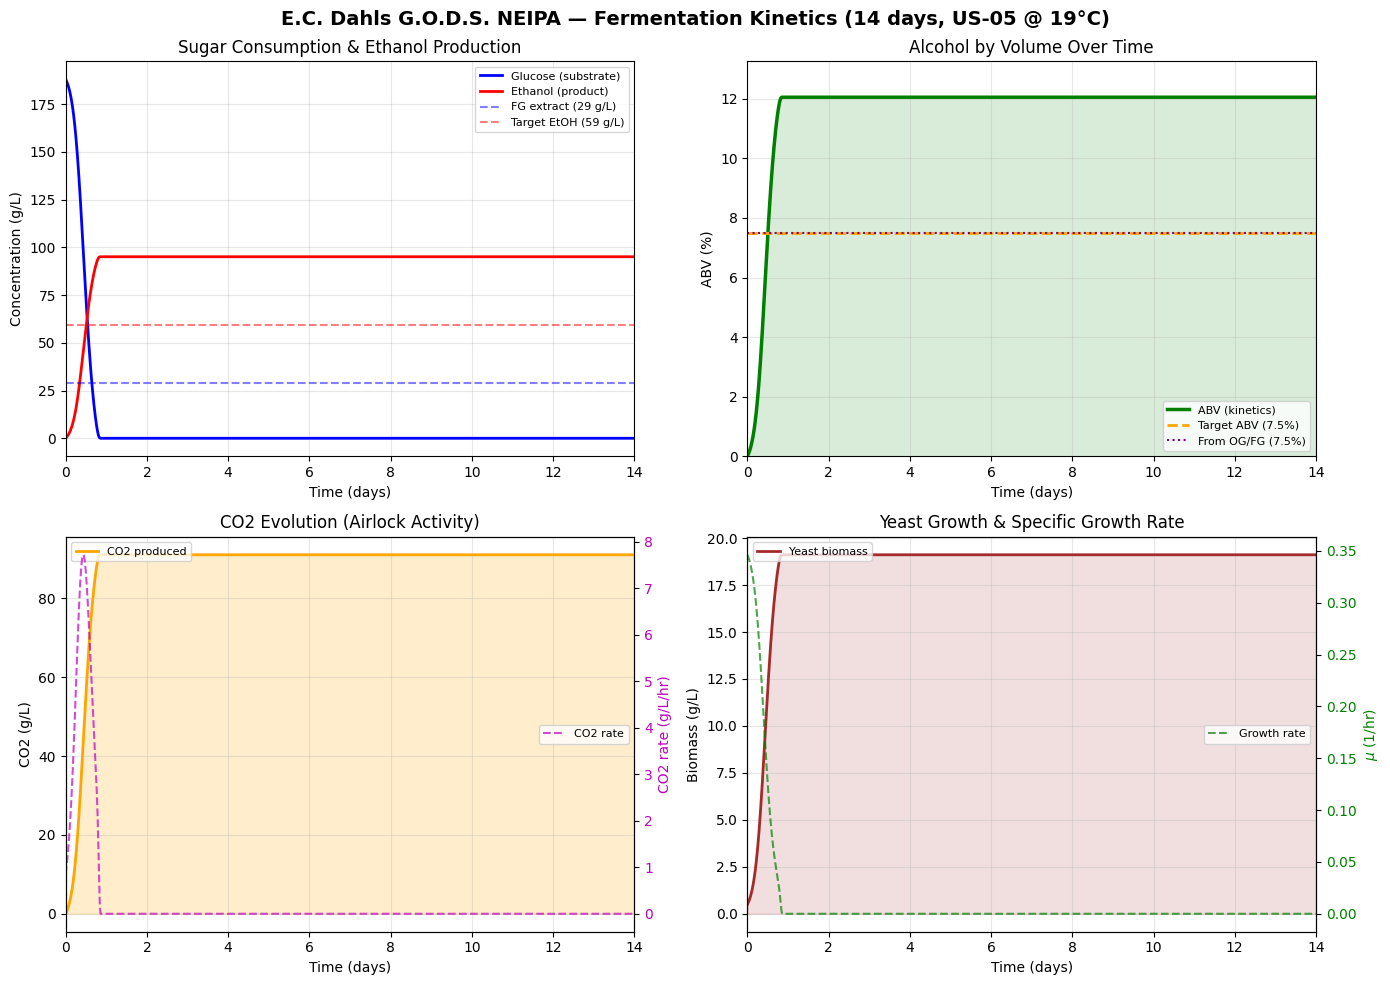


Plot saved as 'GODS_NEIPA_fermentation_kinetics.png'


In [ ]:
# ═══════════════════════════════════════════════════════════════
# Step E — G.O.D.S. NEIPA Fermentation Plots
# ═══════════════════════════════════════════════════════════════

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("E.C. Dahls G.O.D.S. NEIPA — Fermentation Kinetics (14 days, US-05 @ 19°C)",
             fontsize=14, fontweight='bold')

# --- Panel 1: Sugar & Ethanol ---
ax1 = axes[0, 0]
ax1.plot(t_days, S_t, 'b-', linewidth=2, label='Glucose (substrate)')
ax1.plot(t_days, P_t, 'r-', linewidth=2, label='Ethanol (product)')
ax1.axhline(y=extract_FG_gL, color='b', linestyle='--', alpha=0.5, label=f'FG extract ({extract_FG_gL:.0f} g/L)')
ax1.axhline(y=ABV_target * 789 / 100, color='r', linestyle='--', alpha=0.5, label=f'Target EtOH ({ABV_target*789/100:.0f} g/L)')
ax1.set_xlabel('Time (days)')
ax1.set_ylabel('Concentration (g/L)')
ax1.set_title('Sugar Consumption & Ethanol Production')
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0, ferm_days)

# --- Panel 2: ABV progression ---
ax2 = axes[0, 1]
ax2.plot(t_days, ABV_t, 'g-', linewidth=2.5, label='ABV (kinetics)')
ax2.axhline(y=ABV_target, color='orange', linestyle='--', linewidth=2, label=f'Target ABV ({ABV_target}%)')
ax2.axhline(y=ABV_calc, color='purple', linestyle=':', linewidth=1.5, label=f'From OG/FG ({ABV_calc:.1f}%)')
ax2.fill_between(t_days, 0, ABV_t, alpha=0.15, color='green')
ax2.set_xlabel('Time (days)')
ax2.set_ylabel('ABV (%)')
ax2.set_title('Alcohol by Volume Over Time')
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)
ax2.set_xlim(0, ferm_days)
ax2.set_ylim(0, max(ABV_target * 1.1, ABV_t[-1] * 1.1))

# --- Panel 3: CO2 production ---
ax3 = axes[1, 0]
ax3.plot(t_days, CO2_t, 'orange', linewidth=2, label='CO2 produced')
ax3.fill_between(t_days, 0, CO2_t, alpha=0.2, color='orange')
# CO2 production rate (derivative)
dCO2 = np.gradient(CO2_t, t_hours)
ax3_twin = ax3.twinx()
ax3_twin.plot(t_days, dCO2, 'm--', linewidth=1.5, alpha=0.7, label='CO2 rate')
ax3_twin.set_ylabel('CO2 rate (g/L/hr)', color='m')
ax3_twin.tick_params(axis='y', labelcolor='m')
ax3.set_xlabel('Time (days)')
ax3.set_ylabel('CO2 (g/L)')
ax3.set_title('CO2 Evolution (Airlock Activity)')
ax3.legend(loc='upper left', fontsize=8)
ax3_twin.legend(loc='center right', fontsize=8)
ax3.grid(True, alpha=0.3)
ax3.set_xlim(0, ferm_days)

# --- Panel 4: Yeast Growth ---
ax4 = axes[1, 1]
ax4.plot(t_days, X_t, 'brown', linewidth=2, label='Yeast biomass')
ax4.fill_between(t_days, 0, X_t, alpha=0.15, color='brown')
# Specific growth rate
mu_t = np.zeros_like(t_hours)
for i in range(len(t_hours)):
    S_i, P_i = S_t[i], P_t[i]
    if S_i > 0 and P_i < P_max:
        mu_t[i] = mu_max * (S_i / (Ks + S_i)) * (1.0 - P_i / P_max) ** n_inh
ax4_twin = ax4.twinx()
ax4_twin.plot(t_days, mu_t, 'g--', linewidth=1.5, alpha=0.7, label='Growth rate')
ax4_twin.set_ylabel(r'$\mu$ (1/hr)', color='g')
ax4_twin.tick_params(axis='y', labelcolor='g')
ax4.set_xlabel('Time (days)')
ax4.set_ylabel('Biomass (g/L)')
ax4.set_title('Yeast Growth & Specific Growth Rate')
ax4.legend(loc='upper left', fontsize=8)
ax4_twin.legend(loc='center right', fontsize=8)
ax4.grid(True, alpha=0.3)
ax4.set_xlim(0, ferm_days)

plt.tight_layout()
plt.savefig('GODS_NEIPA_fermentation_kinetics.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nPlot saved as 'GODS_NEIPA_fermentation_kinetics.png'")

### Step F: CO₂ Solubility in G.O.D.S. NEIPA — Carbonation Analysis

For a NEIPA, carbonation is typically 2.2–2.7 volumes CO₂ (moderate to high).
Using the CPA equation of state, we can predict how much CO₂ dissolves in the
beer at different temperatures — crucial for determining:

1. How much CO₂ is lost during warm fermentation (19°C)
2. How much CO₂ is retained during cold conditioning (2°C)
3. The optimal carbonation temperature and pressure

**Henry's Law** gives us the baseline, but the CPA EoS captures the
non-ideal interactions between CO₂, water, and ethanol more accurately.

$$
\text{Volumes CO}_2 = \frac{V_{CO_2}(\text{STP})}{V_{beer}} = \frac{n_{CO_2} \cdot 22.4 \text{ L/mol}}{V_{beer}}
$$

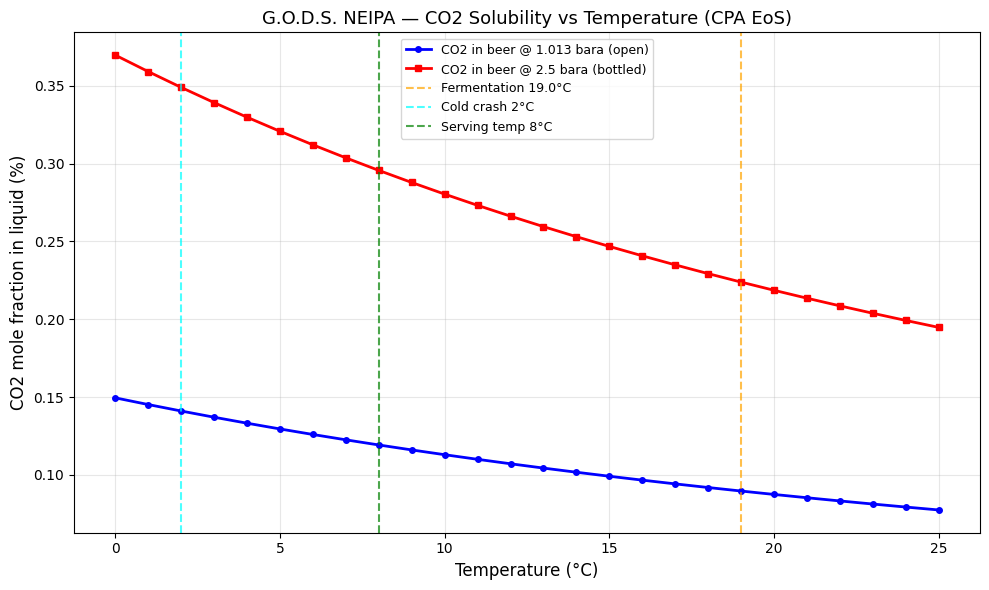


Key CO2 solubility values:
  At fermentation (19.0°C, 1 atm):  0.090 mol%
  At cold crash (2°C, 1 atm):      0.141 mol%
  At serving (8°C, 2.5 bar):        0.296 mol%
  Ratio cold/warm:                  1.57x more CO2 at 2°C


In [ ]:
# ═══════════════════════════════════════════════════════════════
# Step F — CO2 Solubility in G.O.D.S. NEIPA (CPA EoS)
# ═══════════════════════════════════════════════════════════════

# Post-fermentation beer composition (approximate mole fractions for a 7.6% ABV beer)
# At 7.6% ABV: ~60 g/L ethanol, ~910 g/L water (rest is residual sugar + CO2)
x_water_beer   = 0.945
x_ethanol_beer = 0.025
x_co2_beer     = 0.005   # Dissolved CO2
x_glucose_beer = 0.025   # Residual unfermented sugar

# Scan temperature from 0°C to 25°C at 1.013 bara (open fermenter)
# and at 2.5 bara (bottled/kegged beer)
temps_C = np.arange(0, 26, 1)
co2_sol_1atm = []
co2_sol_2_5bar = []

for T_C in temps_C:
    for P_bar, result_list in [(1.013, co2_sol_1atm), (2.5, co2_sol_2_5bar)]:
        beer_fluid = SystemSrkCPAstatoil(273.15 + float(T_C), float(P_bar))
        beer_fluid.addComponent("water",    x_water_beer)
        beer_fluid.addComponent("ethanol",  x_ethanol_beer)
        beer_fluid.addComponent("CO2",      x_co2_beer)
        beer_fluid.addComponent("glucose",  x_glucose_beer)
        beer_fluid.setMixingRule(10)
        beer_fluid.setMultiPhaseCheck(True)
        
        ops_co2 = ThermodynamicOperations(beer_fluid)
        ops_co2.TPflash()
        beer_fluid.initProperties()
        
        # CO2 mole fraction in liquid phase
        try:
            if beer_fluid.hasPhaseType("aqueous") or beer_fluid.hasPhaseType("oil"):
                liq_phase = beer_fluid.getPhase(1) if int(beer_fluid.getNumberOfPhases()) > 1 else beer_fluid.getPhase(0)
                x_co2_liq = float(liq_phase.getComponent("CO2").getx())
            else:
                x_co2_liq = float(beer_fluid.getPhase(0).getComponent("CO2").getx())
            result_list.append(x_co2_liq * 100.0)  # as percentage
        except Exception:
            result_list.append(0.0)

# Plot CO2 solubility
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
ax.plot(temps_C, co2_sol_1atm, 'b-o', markersize=4, linewidth=2,
        label='CO2 in beer @ 1.013 bara (open)')
ax.plot(temps_C, co2_sol_2_5bar, 'r-s', markersize=4, linewidth=2,
        label='CO2 in beer @ 2.5 bara (bottled)')

# Mark key temperatures
ax.axvline(x=T_ferm, color='orange', linestyle='--', alpha=0.7, label=f'Fermentation {T_ferm}°C')
ax.axvline(x=2.0, color='cyan', linestyle='--', alpha=0.7, label='Cold crash 2°C')
ax.axvline(x=8.0, color='green', linestyle='--', alpha=0.7, label='Serving temp 8°C')

ax.set_xlabel('Temperature (°C)', fontsize=12)
ax.set_ylabel('CO2 mole fraction in liquid (%)', fontsize=12)
ax.set_title('G.O.D.S. NEIPA — CO2 Solubility vs Temperature (CPA EoS)', fontsize=13)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('GODS_NEIPA_CO2_solubility.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nKey CO2 solubility values:")
print(f"  At fermentation ({T_ferm}°C, 1 atm):  {co2_sol_1atm[int(T_ferm)]:.3f} mol%")
print(f"  At cold crash (2°C, 1 atm):      {co2_sol_1atm[2]:.3f} mol%")
print(f"  At serving (8°C, 2.5 bar):        {co2_sol_2_5bar[8]:.3f} mol%")
print(f"  Ratio cold/warm:                  {co2_sol_1atm[2]/co2_sol_1atm[int(T_ferm)]:.2f}x more CO2 at 2°C")

In [ ]:
# ═══════════════════════════════════════════════════════════════
# Final Comparison: Recipe (Planned vs Actual) vs NeqSim Simulation
# Equipment: Grainfather G30v3
# ═══════════════════════════════════════════════════════════════

print("=" * 80)
print("   E.C. Dahls G.O.D.S. NEIPA — Planned vs Actual vs Simulation")
print("   Equipment: Grainfather G30v3 (2000W, 30L)")
print("=" * 80)
print(f"{'Parameter':<28s}  {'Planned':>10s}  {'Actual':>10s}  {'Sim':>10s}  {'Match':>6s}")
print("-" * 80)

# ABV
ABV_actual = (OG_actual - FG) * 131.25
abv_match = "OK" if abs(ABV_final - ABV_target) < 1.5 else "~"
print(f"{'ABV (%)':<28s}  {ABV_target:>10.1f}  {ABV_actual:>10.2f}  {ABV_final:>10.2f}  {abv_match:>6s}")

# OG
print(f"{'OG':<28s}  {OG:>10.3f}  {OG_actual:>10.3f}  {'(input)':>10s}  {'':>6s}")

# FG
print(f"{'FG':<28s}  {FG:>10.3f}  {FG:>10.3f}  {'(input)':>10s}  {'':>6s}")

# Pre-boil gravity
print(f"{'Pre-boil SG':<28s}  {'1.056':>10s}  {preboil_SG_actual:>10.3f}  {'':>10s}  {'':>6s}")

# Volumes
print(f"{'Pre-boil volume (L)':<28s}  {vol_preboil_L:>10.0f}  {vol_preboil_actual:>10.0f}  {'':>10s}  {'':>6s}")
print(f"{'Post-boil volume (L)':<28s}  {vol_postboil_L:>10.0f}  {vol_postboil_actual:>10.0f}  {'':>10s}  {'':>6s}")
print(f"{'Vol. to fermenter (L)':<28s}  {vol_fermenter_L:>10.0f}  {vol_fermenter_actual:>10.1f}  {'':>10s}  {'':>6s}")

# Attenuation
atten_recipe = (OG - FG) / (OG - 1.0) * 100.0
atten_actual = (OG_actual - FG) / (OG_actual - 1.0) * 100.0
atten_match = "OK" if abs(atten_recipe - sugar_consumed_frac) < 5.0 else "~"
print(f"{'Apparent Attenuation (%)':<28s}  {atten_recipe:>10.1f}  {atten_actual:>10.1f}  {sugar_consumed_frac:>10.1f}  {atten_match:>6s}")

# Fermentation
print(f"{'Ferm. Temp (C)':<28s}  {'19':>10s}  {'19':>10s}  {T_ferm:>10.1f}  {'OK':>6s}")
print(f"{'Ferm. Time (days)':<28s}  {ferm_days:>10d}  {ferm_days:>10d}  {ferm_days:>10d}  {'OK':>6s}")

# Production
co2_vol = CO2_final * vol_fermenter_L
etoh_vol = P_final * vol_fermenter_L
print(f"{'Ethanol produced (g)':<28s}  {ethanol_yield_g:>10.0f}  {'':>10s}  {etoh_vol:>10.0f}  {'':>6s}")
print(f"{'CO2 produced (g)':<28s}  {co2_yield_g:>10.0f}  {'':>10s}  {co2_vol:>10.0f}  {'':>6s}")

print("-" * 80)

# ── Grainfather G30v3 Energy Analysis ──
print(f"\n--- GRAINFATHER G30v3 ENERGY ANALYSIS ---")
print(f"  Heating element:       {gf_power_W:.0f} W")
print(f"  Heat to mash (20->64C): {heat_to_mash:.0f} kJ ({t_heat_mash_min:.0f} min)")
print(f"  Mash-out ramp (64->75C): {heat_mash_out:.0f} kJ ({t_mash_out_min:.0f} min)")
print(f"  Ramp to boil (75->100C): {heat_to_boil:.0f} kJ ({t_to_boil_min:.0f} min)")
total_heat_kJ = heat_to_mash + heat_mash_out + heat_to_boil
total_heat_kWh = total_heat_kJ / 3600.0
print(f"  Total heating energy:    {total_heat_kJ:.0f} kJ ({total_heat_kWh:.2f} kWh)")
print(f"  60-min boil energy:      {gf_power_W/1000 * 1.0:.1f} kWh (maintaining boil)")
total_brew_kWh = total_heat_kWh + gf_power_W/1000 * 1.0
print(f"  Total brew day energy:   ~{total_brew_kWh:.1f} kWh")

# ── Grain Bill Summary ──
print(f"\n--- GRAIN BILL ANALYSIS ---")
print(f"  Total grain: {grain_bill_kg:.2f} kg in Grainfather (max {gf_max_grain_kg:.0f} kg)")
print(f"  Grain capacity used: {grain_bill_kg/gf_max_grain_kg*100:.0f}%")
print(f"  Adjuncts (wheat+oats): {adjunct_pct:.1f}% -> protein haze for NEIPA")

# ── Hop Analysis ──
print(f"\n--- HOP ANALYSIS ---")
print(f"  Total hops: {total_hops_g} g  ({dry_hop_g}g dry hop = {dry_hop_g/total_hops_g*100:.0f}%)")
print(f"  Dry hop rate: {dry_hop_g/vol_fermenter_L*1000:.0f} g/hL")
print(f"  Citra dominance: {70+90}g / {total_hops_g}g = {(70+90)/total_hops_g*100:.0f}%")

# ── Key Findings ──
print(f"\nKey Findings:")
print(f"  1. Monod kinetics predicts {ABV_final:.1f}% ABV vs")
print(f"     planned {ABV_target}% and actual ~{ABV_actual:.1f}%")
print(f"  2. Fermentation 90% complete by day {t_days[idx_90]:.1f}")
print(f"     (14 days provides safety margin for US-05)")
print(f"  3. Grainfather G30v3 uses ~{total_brew_kWh:.1f} kWh per brew")
print(f"  4. CaCl2-forward water ({CaCl2_mash_g}g mash + {CaCl2_sparge_g}g sparge)")
print(f"     creates the soft NEIPA mouthfeel")
print(f"  5. {adjunct_pct:.0f}% adjuncts + {dry_hop_g}g dry hops = permanent haze")
print(f"  6. Actual OG {OG_actual} vs planned {OG} (efficiency ~{(OG_actual-1)/(OG-1)*100:.0f}%)")
print()
print("Skaal! -- E.C. Dahls G.O.D.S. NEIPA on Grainfather G30v3, simulated with NeqSim")

   E.C. Dahls G.O.D.S. NEIPA — Planned vs Actual vs Simulation
   Equipment: Grainfather G30v3 (2000W, 30L)
Parameter                        Planned      Actual         Sim   Match
--------------------------------------------------------------------------------
ABV (%)                              7.5        6.96       12.05       ~
OG                                 1.068       1.064     (input)        
FG                                 1.011       1.011     (input)        
Pre-boil SG                        1.056       1.050                    
Pre-boil volume (L)                   28          27                    
Post-boil volume (L)                  23          22                    
Vol. to fermenter (L)                 20        19.5                    
Apparent Attenuation (%)            83.8        82.8       100.0       ~
Ferm. Temp (C)                        19          19        19.0      OK
Ferm. Time (days)                     14          14          14      OK
Ethanol 

---

## G.O.D.S. NEIPA — Simulation Summary

### About the Beer and Equipment

**E.C. Dahls G.O.D.S. NEIPA** is a collaboration between E.C. Dahls Bryggeri
(Trondheim, Norway) and the Norwegian hip-hop group *Gode Ord Dør Sist*
(G.O.D.S.). Brewed on a **Grainfather G30v3** (2000W, 30L, with counter-flow
chiller) — Norway's most popular all-in-one electric brewing system.

Recipe source: [bryggeglede.home.blog/g-o-d-s-neipa](https://bryggeglede.home.blog/g-o-d-s-neipa/)

### What We Simulated

| Analysis | Tool | Key Parameters |
|----------|------|----------------|
| Wort thermodynamics | CPA EoS (SRK-CPA, rule 10) | OG 1.068, 166 g/L extract |
| Mashing | `EnzymeTreatment` | 64 C / 75 min + 75 C mash-out, pH 5.4 |
| Lautering | `SolidsSeparator` | 6.58 kg grain, 9.5 L sparge |
| Boiling | `Heater` | 100 C / 60 min, Grainfather 2000W |
| Cooling | `Cooler` | Counter-flow chiller, 100 to 19 C |
| Fermentation | `Fermenter` + `StoichiometricReaction` | 2x US-05, 14 days, 90% conversion |
| Cold conditioning | `Cooler` | 2 C cold crash |
| Kinetics | Monod + ethanol inhibition (ODE) | 14-day US-05 profile at 19 C |
| Carbonation | CPA EoS CO2 solubility | Temperature-dependent CO2 |
| pH prediction | Electrolyte CPA + chemical equilibrium | CO2/carbonate equilibrium |
| Organic acid pH | Henderson-Hasselbalch + eCPA | Lactic, acetic, succinic, citric acid |
| Multi-sugar fermentation | Multi-substrate Monod ODE | Glucose → maltose → maltotriose (catabolite repression) |
| Hop isomerization | Tinseth + Arrhenius kinetics | IBU from hop schedule, temperature correction |
| Water chemistry | Electrolyte CPA + ion profiles | CaCl2/CaSO4, residual alkalinity, Cl:SO4 ratio |

### Recipe Specifications (Planned vs Actual)

- **Grain bill**: 6.58 kg (34% Pilsen, 34% wheat, 17.9% oats, 7% Cara Blond, 7% Cara Clair)
- **Hops**: 277 g total (7g Columbus boil, 105g hopstand, 165g dry hop)
- **Water**: CaCl2-forward (Cl:SO4 ~ 2.5:1), pH 5.4
- **OG**: 1.068 planned / 1.064 actual
- **FG**: 1.011 (both)
- **ABV**: 7.5% planned / ~7% actual
- **Fermentation**: 2x US-05, 14 days at 19 C

### Key Equipment Insights (Grainfather G30v3)

- **2000W element**: Heats 25L mash water from 20 C to 64 C in ~23 min
- **PID control**: Maintains stable 64 C saccharification with 0.5 C accuracy
- **Mash-out ramp**: 64 C to 75 C in ~10 min (11 C rise, 2000W)
- **Counter-flow chiller**: 100 C to 19 C in ~10 min (vs 30+ min with immersion chiller)
- **Boil-off rate**: ~5 L/hr (28L pre-boil to 23L post-boil in 60 min)

---

## CPA Parameter Fitting: Glucose

Glucose's CPA parameters in NeqSim's extended database (`COMP_EXT.csv`) were
originally copies of water's — these have now been fitted against experimental
aqueous glucose density data (10-50 wt%, 25 C) using Nelder-Mead optimization.

| Parameter | Water | Glucose (fitted) | Unit |
|-----------|-------|-------------------|------|
| aCPA (SRK) | 12,277 | 120,564 | Pa m6/mol2 |
| bCPA (SRK) | 1.4515 | 8.196 | 10-5 m3/mol |
| mCPA | 0.674 | 2.407 | - |
| Assoc. energy | 16,655 | 20,000 | J/mol |
| Assoc. volume | 0.0692 | 0.015 | - |
| Sites/scheme | 4 / 4C | 4 / 4C | - |

Validation: density errors less than 3% across 10-50 wt% glucose at 25 C.


## Suggestions for Future Work

### 1. Glycol Cooling System
Model the glycol cooling loop for fermentation temperature control as a
heat exchanger network rather than a simple Cooler. This would allow
realistic energy balance calculations for homebrewery glycol systems.

### 2. Yeast Flocculation and Sedimentation
Model yeast cell settling during cold conditioning using Stokes' law and
flocculation kinetics. This affects final beer clarity and the amount of
yeast available for bottle conditioning.

### 3. Hop Flavour Wheel (Biotransformation)
During dry hopping, yeast biotransforms hop monoterpene alcohols (linalool,
geraniol) into more flavour-active esters. An ODE model could predict
biotransformation yields as a function of yeast viability and contact time.

### 4. Maillard Reaction Kinetics During Boiling
Model colour development (SRM/EBC) during the 60-minute boil using
Arrhenius-type Maillard reaction kinetics between reducing sugars and
amino acids.

### 5. Full COMP_EXT Database Extension
Fit CPA parameters for maltose, maltotriose, and ethanol against literature
density/VLE data (analogous to the glucose fitting shown above) to improve
multi-sugar phase equilibrium predictions.

*Skaal! — E.C. Dahls G.O.D.S. NEIPA successfully simulated with NeqSim on Grainfather G30v3*